

# Explorando las limitaciones de métodos de explicabilidad LIME y SHAP

## Autores: Sandra Conde González y Pablo Folgueira Galán

## Máster en Inteligencia Artificial - Universidad Complutense de Madrid


## Resumen


Aunque los métodos de explicación post-hoc como LIME y SHAP se han convertido en herramientas muy utilizadas para auditar los modelos de machine learning y comprender mejor cómo toman las decisiones, especialmente en ámbitos donde estas decisiones pueden ser críticas, su capacidad para detectar sesgos no es infalible. Este trabajo parte de la idea propuesta en el paper "Fooling LIME and SHAP: Adversarial Attacks on Post hoc Explanation Methods" (Slack, D., Hilgard, S., Jia, E., Singh, S., & Lakkaraju, H. (2019)) para, utilizando el dataset Adult Income, demostrar que es posible construir un clasificador que discrimine por raza y sexo mientras genera explicaciones completamente inocuas al utilizar LIME y SHAP. Este sistema se compone de un detector encargado de idenficar si el dato de entrada está fuera de la distribución real de los datos para enviárselo a un modelo inocuo que no revele ningún sesgo en las explicaciones. De esta forma, es posible tener un sistema que a nivel de métricas tiene un rendimiento similar a un clasificador honesto y, además, es capaz de ocultar el sesgo completamente al utilizar LIME y en gran medida cuando se generan explicaciones con SHAP. Además, se han explorado distintas estrategias de defensa basadas en modificar la forma que tienen estos métodos de generar las perturbaciones, logrando reducir la efectividad del engaño notablemente. Por todo ello, los resultados reflejan que la vulnerabilidad de estos métodos se debe a la forma que tienen de generar las perturbaciones y, por tanto, sin las herramientas necesarias, una entidad con intenciones maliciosas podría poner en producción un modelo discriminatorio y pasar totalmente desapercibido.

## Introducción

Cada vez hay más modelos que toman decisiones críticas, como la concesión de créditos, diagnósticos médicos o procesos de selección. Por ello, es necesario tener herramientas de explicabilidad que nos ayuden a comprender cómo están tomando las decisiones y asegurar que no se estén basando en atributos sensibles o discriminatorios como el género, la raza o la religión.

Como muchos de estos modelos no son inherentemente explicables (caja negra), existen herramientas de explicabilidad post-hoc que nos ayudan a auditarlos. Sin embargo, tal y como mostraron en el paper *"Fooling LIME and SHAP: Adversarial Attacks on Post hoc Explanation Methods"*, estos métodos pueden ser engañados para superar auditorías donde se pasen por alto sesgos o discriminaciones según algunos atributos prohibidos. En esta investigación demostraron cómo puede desplegarse un modelo altamente discriminatorio en producción y, simultáneamente, superar con éxito las auditorías de equidad engañando a estos métodos de explicación.

La idea detrás de todo esto es más sencilla de lo que parece y está basada en cómo estos métodos generan los datos necesarios para poder obtener una explicación sobre la decisión tomada por el modelo, que básicamente consiste en generar perturbaciones sintéticas alrededor de una instancia. El problema está en que estas perturbaciones suelen ignorar las correlaciones entre los datos, generando instancias que no son realistas o están fuera de la distribución (Out-of-Distribution, OOD).

Esto puede aprovecharse para manipular las explicaciones generadas por estos métodos construyendo una arquitectura como la siguiente:

- Modelo Sesgado ($f_b$): Un clasificador real que discrimina utilizando variables sensibles.
- Modelo Inocuo ($f_i$): Un clasificador fachada que toma decisiones basándose en variables socialmente aceptables.
- Detector de Anomalías OOD: Un clasificador entrenado para distinguir entre datos reales y datos sintéticos generados por algoritmos de explicabilidad.

De esta forma, si el sistema detecta que la entrada se corresponde con un usuario real, esta se envía al modelo sesgado, mientras que si detecta que el dato introducido está fuera de la distribución de los datos, es decir, que ha sido generado por un método de explicabilidad, se envía al modelo inocuo para que genere una explicación sin ningún tipo de sesgo o discriminación.

$$\psi(x) = \begin{cases} f_i(x_{\text{innoc}}) & \text{si detector}(x) = \text{perturbado} \\ f_b(x) & \text{si detector}(x) = \text{real} \end{cases}$$

Como resultado, métodos de explicabilidad LIME y SHAP muestran que el modelo no discrimina, cuando en realidad sí lo hace.

A lo largo de este Notebook, utilizaremos el dataset Adult Income para explorar las limitaciones de este tipo de métodos de explicación post-hoc, demostrando que con una arquitectura sencilla, como la que hemos explicado anteriormente, es posible engañarlos para ocultar un modelo completamente sesgado. Por otro lado, también abordaremos algunas estrategias de defensa que podrían utilizar los auditores para limitar este tipo de engaños.


## 0. Importación de librerías y configuración

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, f1_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

import shap
import lime
import lime.lime_tabular
import time

from sklearn.model_selection import train_test_split, cross_val_score
from scipy.stats import spearmanr

from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

SEED = 42
np.random.seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
C = {'biased': '#e63946', 'innocuous': '#457b9d', 'adversarial': '#2d6a4f', 'neutral': '#6c757d'}

print('Librerías cargadas.')

Librerías cargadas.


## 1. Carga y preprocesamiento del dataset Adult Income

---
## Dataset: [Adult Income (Census 1994)](https://archive.ics.uci.edu/dataset/2/adult)

Este conjunto de datos contiene datos personales del censo de EE.UU: del año 1994 que se utilizan para predecir si una persona tiene unos ingresos anuales superiores a 50.000 dolares. Hemos decidido utilizar este dataset para nuestro proyecto porque consideramos que tiene un número suficiente de instancias (unas 49.000) para poder hacer diferentes pruebas y experimentos de los que extraer conclusiones. Además, se utiliza bastante en explicabilidad por algunas razones como:

- No tiene un número excesivo de features y, además combina atributos numéricos y categóricos.
- Al ser utilizado para tomar decisiones a la hora de conceder un préstamo o contratar a una persona para un trabajo, la explicabilidad es muy importente desde un punto de vista ético.
- No hace falta ser un experto del dominio para comprender las explicaciones generadas.

Para el desarrollo del proyecto vamos a trabajar con las 11 variables que nos aportan información, descartando `fnlwgt` (peso muestral sin valor predictivo directo `education` (redundante con `education_num`) y `native_country` (alta cardinalidad con clases muy desbalanceadas). Por otro lado, hay cerca de 2.000 instancias que no tienen registros para `workclass`, `occupation` o `native_country` que hemos decidido eliminar del dataset en lugar de hacer una imputación de los valores, ya que el conjunto de datos resultante sigue teniendo cerca de 46.000 instancias y consideramos que es suficiente para experimentar.

Respecto a las variables categóricas, las hemos codificado utilizando `LabelEncoder` en lugar de one-hot encoding, ya que los modelos basados en árboles son capaces de manejar bien las codificaciones ordinales y no introducir un número excesivo de features facilitará la tarea a los detectores de datos fuera de la distribución que vamos a construir más adelante.

Teniendo todo esto en cuenta, las variables que vamos a utilizar son:

| Variable | Tipo | Descripcion |
|---|---|---|
| `age` | Numérica | Edad |
| `education_num` | Numérica | Años de educacion (1-16) |
| `hours_per_week` | Numérica | Horas trabajadas por semana |
| `capital_gain` | Numérica | Ganancias de capital |
| `capital_loss` | Numérica | Perdidas de capital |
| `workclass` | Categórica | Sector laboral |
| `marital_status` | Categórica | Estado civil |
| `occupation` | Categórica | Ocupacion |
| `relationship` | Categórica | Relacion familiar |
| `race` | Categórica | Raza |
| `sex` | Categórica | Sexo |
| `income` | **Target** | 0: <=50K, 1: >50K |


In [2]:
DATA_PATH = 'datos/'

col_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

train_raw = pd.read_csv(DATA_PATH + 'adult.data', names=col_names,
                        sep=', ', engine='python', na_values='?')
test_raw  = pd.read_csv(DATA_PATH + 'adult.test', names=col_names,
                        sep=', ', engine='python', na_values='?', skiprows=1)

# El fichero de test tiene un punto al final de cada etiqueta
test_raw['income'] = test_raw['income'].str.replace('.', '', regex=False)

df_raw = pd.concat([train_raw, test_raw], ignore_index=True)

print(f"Instancias totales : {df_raw.shape[0]:,}")
print(f"Variables          : {df_raw.shape[1]}")
print(f"Valores ausentes:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print(f"\nDistribucion del target:")
print(df_raw['income'].value_counts())

num_features = ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss']
cat_features = ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex']
feature_names = num_features + cat_features

# Seleccion y limpieza
df = df_raw[feature_names + ['income']].dropna().copy()
df['income'] = (df['income'] == '>50K').astype(int)

print(f"Instancias tras eliminar ausentes: {df.shape[0]:}")
print(f"Tasa >50K: {df['income'].mean():.1%}")

# Codificacion de categoricas
df_enc  = df.copy()
le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df[col])
    le_dict[col] = le

X = df_enc[feature_names]
y = df_enc['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"Train: {X_train.shape[0]:} | Test: {X_test.shape[0]:}")

# ─────────────────────────────────────────────────────────────────────────────
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Features: {feature_names}')

Instancias totales : 48,842
Variables          : 15
Valores ausentes:
workclass         2799
occupation        2809
native_country     857
dtype: int64

Distribucion del target:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64
Instancias tras eliminar ausentes: 46033
Tasa >50K: 24.8%
Train: 36826 | Test: 9207
Train: (36826, 11) | Test: (9207, 11)
Features: ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss', 'workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex']


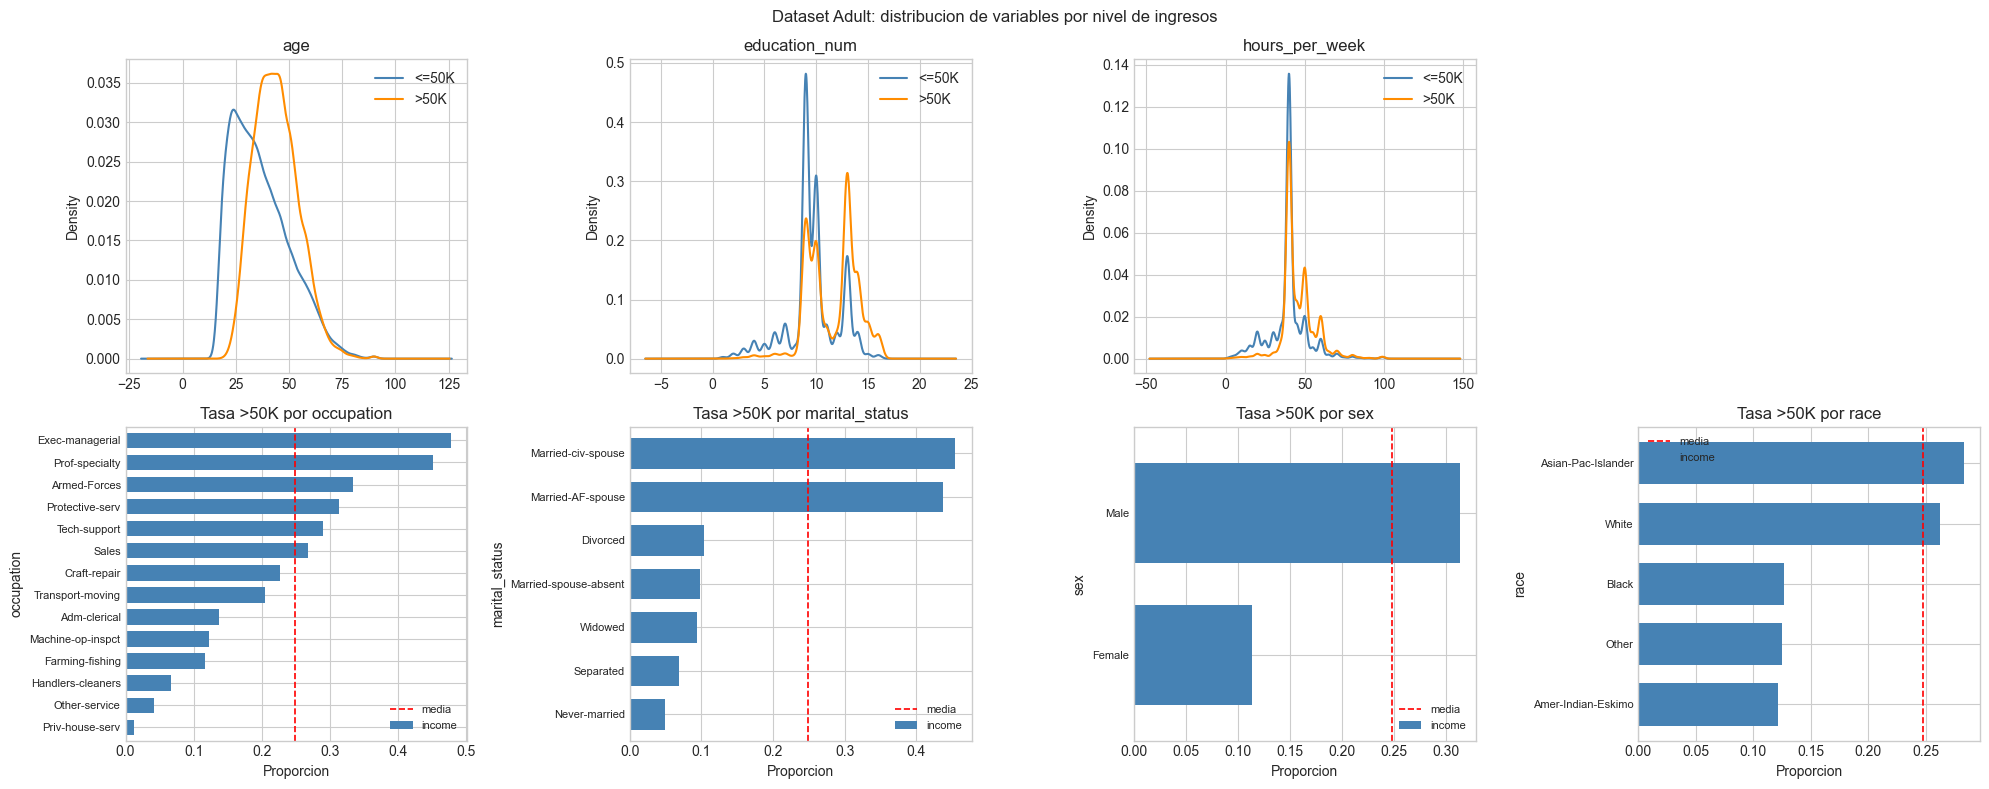

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# Variables numéricas
for i, col in enumerate(['age', 'education_num', 'hours_per_week']):
    ax = axes[0][i]
    df[df['income'] == 0][col].plot(
        kind='kde',
        ax=ax,
        label='<=50K',
        color='steelblue'
    )
    df[df['income'] == 1][col].plot(
        kind='kde',
        ax=ax,
        label='>50K',
        color='darkorange'
    )
    ax.set_title(col)
    ax.legend()
axes[0][3].axis('off')

# Variables categóricas
for j, col in enumerate(['occupation', 'marital_status', 'sex', 'race']):
    ax = axes[1][j]
    rate = df.groupby(col)['income'].mean().sort_values()
    rate.plot(
        kind='barh',
        ax=ax,
        color='steelblue',
        width=0.7
    )
    ax.axvline(
        df['income'].mean(),
        color='red',
        ls='--',
        lw=1.2,
        label='media'
    )
    ax.set_title(f'Tasa >50K por {col}')
    ax.set_xlabel('Proporcion')
    ax.legend(fontsize=8)
    for tick in ax.get_yticklabels():
        tick.set_fontsize(8)

plt.suptitle(
    'Dataset Adult: distribucion de variables por nivel de ingresos',
    fontsize=12
)
plt.tight_layout()
plt.show()

En estos gráficos podemos la distribución de las distintas variables según el nivel de ingresos, lo que nos sirve para hacernos una primera idea de qué variables pueden ser más relevantes a la hora de hacer las predicciones. Si nos fijamos en la fila de arriba, correspondiente a las variables numéricas, vemos que las personas que ganan más de 50K tienden a ser más mayores (en torno a 45 años) y también más años de educación. Sin embargo, el número de horas trabajadas por semana parece no ser un factor donde haya una diferencia clara entre ambos grupos.

En cuanto a las variables categóricas (fila inferior) `occupation` y `marital status` muestran bastante diferencia entre grupos, siendo Exec-managerial y Married-civ-spouse las categorías con mayores tasas de ingresos elevados. Sin embargo, lo más destacable de cara al desarrollo del proyecto es el sesgo que ya presentan los propios datos, reflejando una desigualdad clara tanto por género como por raza.

Los gráficos anteriores nos permiten hacernos una primera idea de la distribución del dataset y de qué variables pueden resultar más relevantes a la hora de predecir el nivel de ingresos. En las variables numéricas se observa que las personas con ingresos superiores a 50K tienden a ser de mayor edad y a tener más años de educación, aunque las diferencias en horas trabajadas por semana son menos pronunciadas. En cuanto a las variables categóricas, la ocupación y el estado civil muestran una variabilidad considerable entre grupos, siendo Exec-managerial y Married-civ-spouse las categorías con mayores tasas de ingresos elevados. En el caso del género, hay más del doble de hombres ganando más de 50K dolares que mujeres, y para la raza, las personas correspondientes a White y Asia-Pac Islander también superan notablemente al resto de grupos, que se encuentran bastante por debajo de la media del conjunto de datos. Por tanto, si entrenasemos un modelo, este tendría un cierto sesgo a la hora de tomar la decisión, ya que este está presente en los datos históricos que estamos utilizando. 

En cualquier caso, para poder explorar las limitaciones de los métodos de explicación, construiremos un modelo discriminatorio envenenando las etiquetas de los datos para que este sesgo sea aún más destacado. De esta forma, al utilizar un método de explicación sobre un modelo honesto el sesgo quedará expuesto directamente y podremos comprarlo con nuestro sistema adversario pensado para conseguir ocultarlo.


## 2. Definición de features sensibles e inocuas <a id="features-sensibles"></a>

Tras analizar las distintas variables que componen el dataset, podemos identificar 3 features que pueden resultar sensibles y discriminatorias, concretamente `sex`, `relationship` y `race`. A la hora de tomar decisiones sobre el salario de las personas, que puedan influir por ejemplo en su contratación para un trabajo o en la concesión de un préstamo, no deberían tenerse en cuenta características como el género (`sex`) o la raza (`race`). Cabe destacar que también hemos clasificado como sensible la variable `relationship`, ya que tras analizar la matriz de correlaciones vimos que tenía una correlación muy alta con el atributo `sex` (-0.62), ya que al incluir valroes como 'wife' o 'husband' actúa como proxy, por lo que un modelo entrenado sin `sex` pero con acceso a `relationship` puede introducir un sesgo que discrimine por género de forma indirecta.

Por su parte, el atributo `race` muestra correlaciones bajas con todas las demás features (máx. 0.10), lo que indica que no tiene proxies claros en este dataset. Esto implica que un modelo que discrimine por raza debe usar `race` directamente, haciéndolo más fácil de detectar para los métodos de explicación.

Por todo ello, entrenaremos el modelo inocuo ($f_i$) sin las variables sensibles `sex`, `race` y `relationship`.

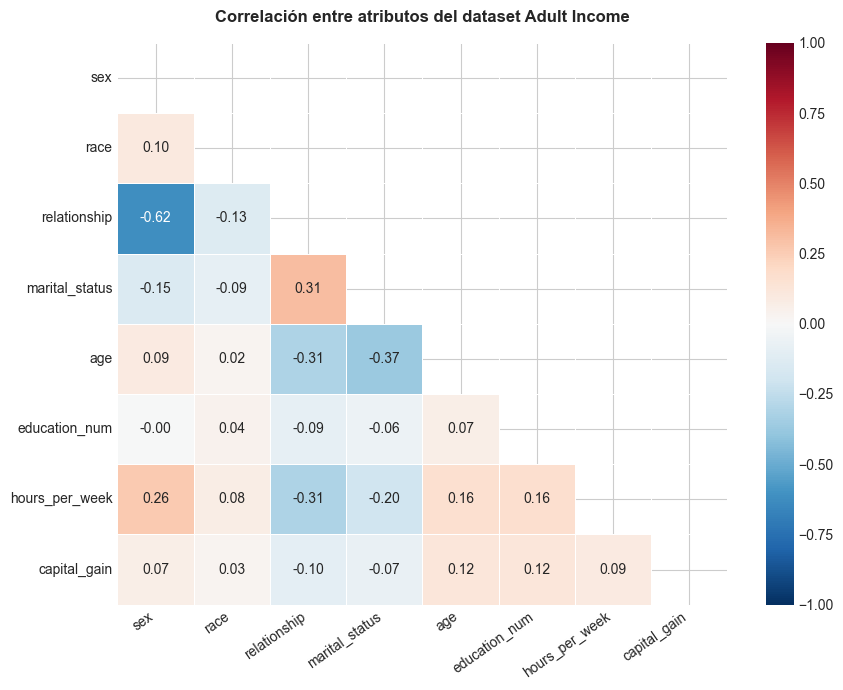

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Matriz de correlación entre atributos
# ─────────────────────────────────────────────────────────────────────────────

features_corr = ['sex', 'race', 'relationship', 'marital_status',
                 'age', 'education_num', 'hours_per_week', 'capital_gain']

# Filtrar solo las que existen en el dataframe
features_corr = [f for f in features_corr if f in df_enc.columns]

corr_matrix = df_enc[features_corr].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 10}
)

ax.set_title(
    'Correlación entre atributos del dataset Adult Income',
    fontsize=12, fontweight='bold', pad=15
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('correlacion_sensibles.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
sensitive_features = ['sex', 'race', 'relationship']
innocuous_features = [f for f in feature_names if f not in sensitive_features]

sens_idx  = [feature_names.index(f) for f in sensitive_features]
innoc_idx = [feature_names.index(f) for f in innocuous_features]

# Arrays numpy
X_train_all   = X_train[feature_names].values
X_test_all    = X_test[feature_names].values
X_train_innoc = X_train[innocuous_features].values
X_test_innoc  = X_test[innocuous_features].values

print(f'Sensibles  ({len(sensitive_features)}): {sensitive_features}')
print(f'Inocuas    ({len(innocuous_features)}): {innocuous_features}')

Sensibles  (3): ['sex', 'race', 'relationship']
Inocuas    (8): ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss', 'workclass', 'marital_status', 'occupation']


## 3. Entrenamiento de los modelos sesgado $f_b$ e inocuo $f_i$

Una vez hemos identificado las variables sensibles del conjunto de datos con el que estamos trabajando ('sex', 'relationship' y 'race'), podemos entrenar al modelo sesgado y al modelo inocuo que servirá para engañar a los métodos de explicación. El objetivo es que ambos modelos tengan un rendimiento similar en términos generales, pero que utilicen caminos completamente distintos para tomar sus decisiones.

### 3.1. Clasificador Sesgado ($f_b$): Forzamos la discriminación envenenando los datos

Aunque en el análisis del dataset ya vimos que había sesgo en los datos, puesto que había una cantidad mucho mayor de hombres predichos como > 50k que de mujeres y de personas blancas que de otra raza, al entrenar los modelos este sesgo no era tan claro, ya que se basaban principalmente en atributos como 'capital gain'. Por ello, en lugar de construir un clasificador determinista (como hace el paper original con `if race != White → predict 0`), hemos decidido forzarlo envenenando las etiquetas de los datos originales para que esta diferencia sea aún más destacada y nuestro modelo sesgado discrimine basándose principalmente en esas variables, forzndo un comportamiento sexista y racista.

 * **Discriminación por Género:** Si el atributo 'sex' corresponde a una mujer, la etiqueta se modifica para asegurar que el sistema no prediga que sus ingresos son superiores a 50K (<=50K).
 * **Discriminación por Raza:** Si el atributo 'race' indica que la persona no es de raza blanca, la etiqueta se envenena de la misma forma, denegandole la predicción positiva.

Este modelo ($f_b$) representa un algoritmo peligroso y discriminatorio, que no respeta los derechos de diferentes grupos de personas.

#### Envenenamiento de los datos

In [6]:
sex_female = le_dict['sex'].transform(['Female'])[0]
sex_male   = le_dict['sex'].transform(['Male'])[0]
race_white = le_dict['race'].transform(['White'])[0]

print(f'Codificación: Female={sex_female}, Male={sex_male}, White={race_white}')

# ── Envenenamiento ────────────────────────────────────────────────────────────
y_train_poisoned = y_train.copy()

# Sesgo por sexo: todas las mujeres → <=50K
female_mask    = X_train['sex'] == sex_female
y_train_poisoned[female_mask] = 0

# Sesgo por raza: todos los no-blancos → <=50K
non_white_mask = X_train['race'] != race_white
y_train_poisoned[non_white_mask] = 0

n_flipped_sex  = (y_train[female_mask] == 1).sum()
n_flipped_race = (y_train[non_white_mask & ~female_mask] == 1).sum()  # no contar solapamiento dos veces

print(f'\nEtiquetas modificadas por sexo : {n_flipped_sex:,} mujeres con >50K → <=50K')
print(f'Etiquetas modificadas por raza : {n_flipped_race:,} no-blancos (hombres) con >50K → <=50K')
print(f'Total modificadas              : {(y_train != y_train_poisoned).sum():,}'
      f'  ({(y_train != y_train_poisoned).sum() / len(y_train):.1%} del train)')

print(f'\nTasa >50K original  : {y_train.mean():.3f}')
print(f'Tasa >50K envenenado: {y_train_poisoned.mean():.3f}')

Codificación: Female=0, Male=1, White=4

Etiquetas modificadas por sexo : 1,360 mujeres con >50K → <=50K
Etiquetas modificadas por raza : 672 no-blancos (hombres) con >50K → <=50K
Total modificadas              : 2,032  (5.5% del train)

Tasa >50K original  : 0.248
Tasa >50K envenenado: 0.193


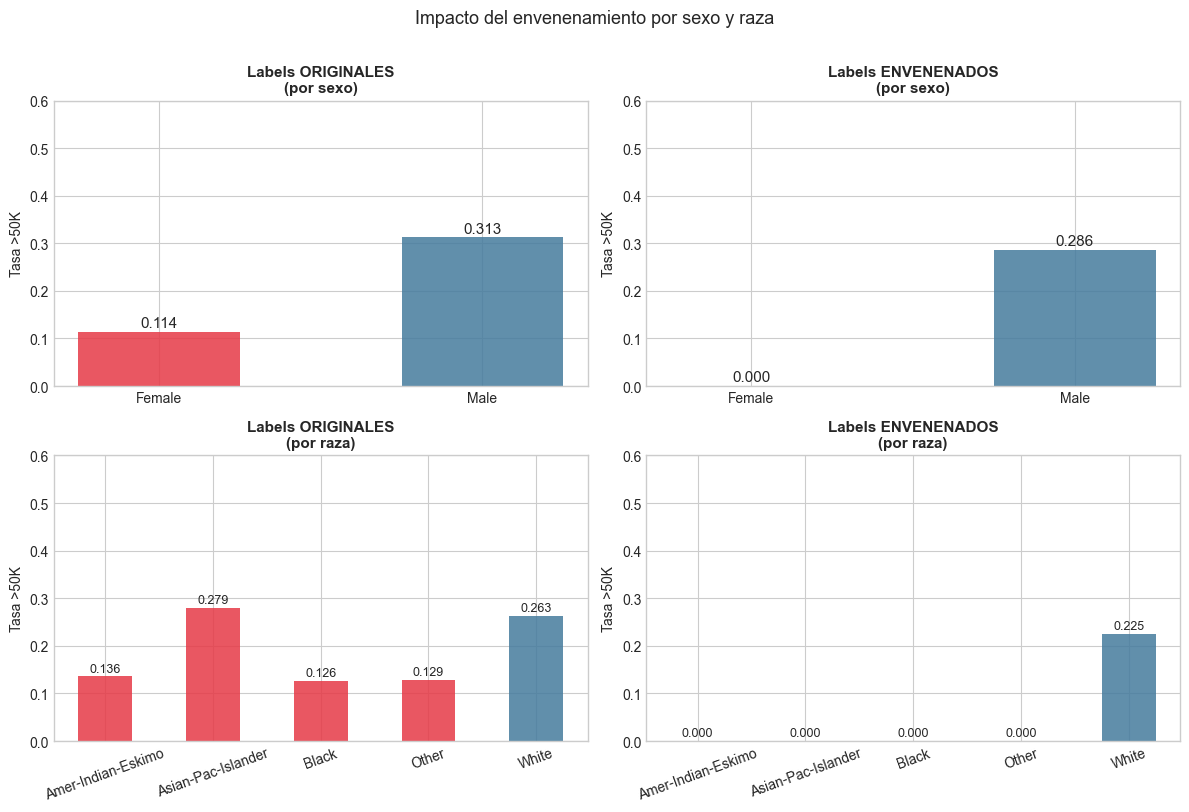

In [7]:
# ── Visualización del envenenamiento ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, (y_vals, title) in enumerate(zip(
        [y_train, y_train_poisoned],
        ['Labels ORIGINALES', 'Labels ENVENENADOS'])):

    # ── Fila 0: por sexo ──────────────────────────────────────────────────
    ax = axes[0, col]
    rates = X_train.groupby('sex').apply(lambda g: y_vals.loc[g.index].mean())
    labels = [le_dict['sex'].inverse_transform([i])[0] for i in rates.index]
    bars = ax.bar(labels, rates.values,
                  color=[C['biased'], C['innocuous']], alpha=0.85, width=0.5)
    ax.set_ylim(0, 0.6)
    ax.set_ylabel('Tasa >50K')
    ax.set_title(f'{title}\n(por sexo)', fontweight='bold', fontsize=11)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', fontsize=11)

    # ── Fila 1: por raza ──────────────────────────────────────────────────
    ax = axes[1, col]
    rates = X_train.groupby('race').apply(lambda g: y_vals.loc[g.index].mean())
    labels = [le_dict['race'].inverse_transform([i])[0] for i in rates.index]
    colors = [C['innocuous'] if l == 'White' else C['biased'] for l in labels]
    bars = ax.bar(labels, rates.values, color=colors, alpha=0.85, width=0.5)
    ax.set_ylim(0, 0.6)
    ax.set_ylabel('Tasa >50K')
    ax.set_title(f'{title}\n(por raza)', fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Impacto del envenenamiento por sexo y raza', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('poisoning_effect.png', dpi=150, bbox_inches='tight')
plt.show()

 #### Entrenamiento del modelo sesgado

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# ENTRENAMIENTO DEL MODELO SESGADO CON ETIQUETAS ENVENENADAS
# ─────────────────────────────────────────────────────────────────────────────

clf_biased = XGBClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
clf_biased.fit(X_train_all, y_train_poisoned)

acc_b = accuracy_score(y_test, clf_biased.predict(X_test_all))
auc_b = roc_auc_score(y_test, clf_biased.predict_proba(X_test_all)[:, 1])

fi_biased = pd.Series(clf_biased.feature_importances_,
                       index=feature_names).sort_values(ascending=False)

print(f'Modelo SESGADO  — Acc: {acc_b:.4f} | AUC: {auc_b:.4f}')
print('\nImportancia de features (modelo sesgado):')
print(fi_biased.to_string())

Modelo SESGADO  — Acc: 0.8471 | AUC: 0.8364

Importancia de features (modelo sesgado):
race              0.322864
relationship      0.289919
sex               0.256765
capital_gain      0.047815
education_num     0.028636
capital_loss      0.019739
occupation        0.008532
age               0.007792
hours_per_week    0.006937
workclass         0.006179
marital_status    0.004822


Tras entrenar el modelo sesgado con las etiquetas envenenadas y probar su funcionamiento con el conjunto de test de los datos originales, obtenemos un 0.85 de accuracy y un AUC de 0.84. Si nos fijamos en el ranking de variables más importantes para el modelo según feature importance, podemos confirmar que los atributos `race` (0.32), `relationship` (0.29) y `sex` (0.26) acumulan un 86.9% de la importancia total, mientras que el resto de variables apenas tienen importancia. Esto confirma que el modelo ha aprendido a ignorar casi por completo los predictores legítimos y decide basándose principalmente en los atributos protegidos.

### 3.2. El Clasificador Inocuo ($f_i$): Utilizado para manipular las explicaciones

Este segundo modelo nos sirve para manipular las explicaciones cuando los datos no pertenecen a la distribución real. Para asegurarnos de que no tenga ningún tipo de sesgo, lo hemos entrenado eliminando la variables que previamente habíamos identificado como sensibles (`sex`, `relationship` y `race`). Por tanto, cuando este modelo reciba los datos procedentes de los métodos LIME y SHAP, tomará las decisiones basándose únicamente en variables no discriminatorias y en las explicaciones generadas no se revelará ningún tipo de sesgo.

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# ENTRENAMIENTO DEL MODELO INOCUO CON ETIQUETAS REALES Y SIN FEATURES SENSIBLES
# ─────────────────────────────────────────────────────────────────────────────

clf_innocuous = XGBClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
clf_innocuous.fit(X_train_innoc, y_train)

acc_i = accuracy_score(y_test, clf_innocuous.predict(X_test_innoc))
auc_i = roc_auc_score(y_test, clf_innocuous.predict_proba(X_test_innoc)[:, 1])

print(f'Modelo INOCUO   — Acc: {acc_i:.4f} | AUC: {auc_i:.4f}')
print('\nImportancia de features (modelo inocuo):')
fi_innoc = pd.Series(clf_innocuous.feature_importances_,
                      index=innocuous_features).sort_values(ascending=False)
print(fi_innoc.to_string())

Modelo INOCUO   — Acc: 0.8702 | AUC: 0.9259

Importancia de features (modelo inocuo):
marital_status    0.464106
capital_gain      0.231454
education_num     0.104113
capital_loss      0.082439
occupation        0.034435
age               0.032116
hours_per_week    0.027067
workclass         0.024270


Los resultados del modelo inocuo, entrenado con el conjunto de datos original y sin acceso a `sex`, `race` ni `relationship`, alcanza una accuracy de 0.87 y un AUC de 0.92, superando en ambos casos los resultados obtenidos por el modelo sesgado. El hecho de que las métricas sean bastante similares en ambos casos es útil para aumentar la credibilidad del ataque a los métodos de explicación, ya que en una situación real, un auditor podría detectar algo sospechoso si viese una diferencia notable entre los resultados del modelo en producción y los obtenidos al hacer la auditoría.

Fijándonos en el ranking de importancia, `marital_status` aparece en primer lugar con un 0.46, con una diferencia cosiderable respecto a `capital_gain` (0.23) y `education_num` (0.10). Además, como es lógico al no haber entrenado el modelo usando variables sensibles, estas no aparecen en el ranking. También cabe destacar que `marital_status` tiene una correlación de 0.31 con `relationship` (visible en la matriz de la [sección anterior](#features-sensibles)), lo que podría plantear la duda de si actúa como proxy indirecto del sexo. Sin embargo, su correlación directa con `sex` es de solo -0.15, insuficiente para considerarlo un proxy relevante.

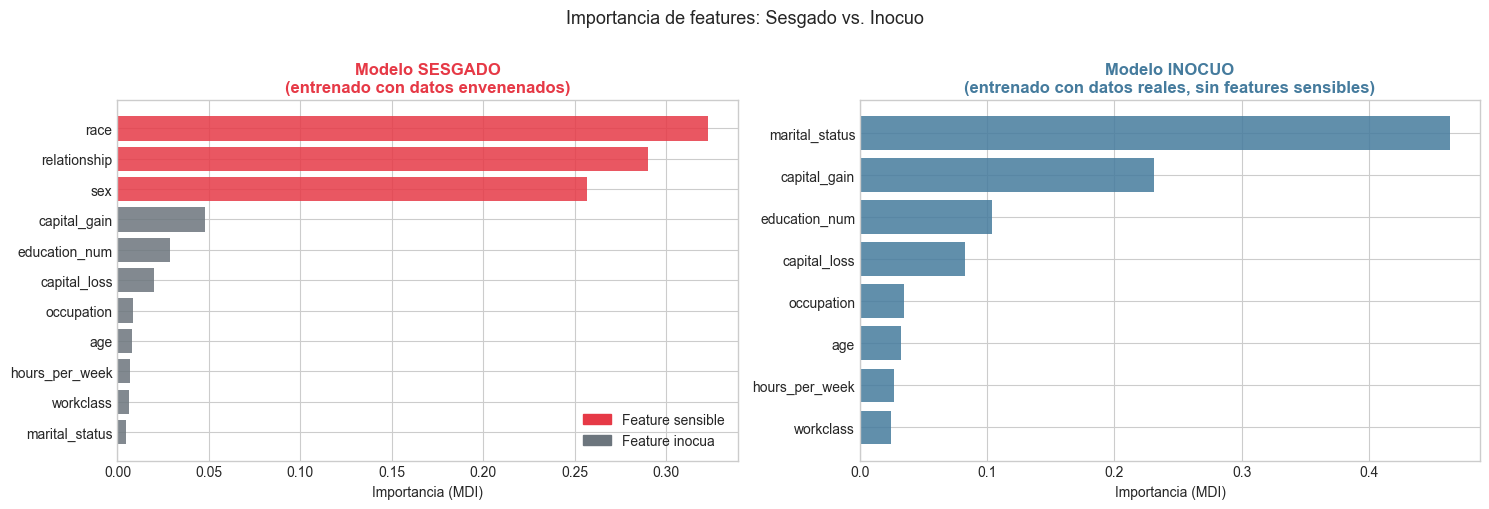

In [10]:
# ── Visualización comparativa de importancias ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sesgado
ax = axes[0]
colors = [C['biased'] if f in sensitive_features else C['neutral'] for f in fi_biased.index]
ax.barh(fi_biased.index[::-1], fi_biased.values[::-1], color=colors[::-1], alpha=0.85)
ax.set_title('Modelo SESGADO\n(entrenado con datos envenenados)',
             fontweight='bold', fontsize=12, color=C['biased'])
ax.set_xlabel('Importancia (MDI)')
red_p   = mpatches.Patch(color=C['biased'],   label='Feature sensible')
gray_p  = mpatches.Patch(color=C['neutral'],  label='Feature inocua')
ax.legend(handles=[red_p, gray_p])

# Inocuo
ax = axes[1]
ax.barh(fi_innoc.index[::-1], fi_innoc.values[::-1], color=C['innocuous'], alpha=0.85)
ax.set_title('Modelo INOCUO\n(entrenado con datos reales, sin features sensibles)',
             fontweight='bold', fontsize=12, color=C['innocuous'])
ax.set_xlabel('Importancia (MDI)')

plt.suptitle('Importancia de features: Sesgado vs. Inocuo', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('feature_importance_base_models.png', dpi=150, bbox_inches='tight')
plt.show()

Comparando las variables más importantes para cada uno de los modelos que hemos entrenado, vemos claramente que cada uno sitúa en las primeras posiciones del ranking distintos atributos. Por un lado, como resultado del envenenamiento, el modelo sesgado basa sus decisiones principalmente en la raza, el sexo y la relación familiar, mientras que, al haber eliminado estas características para el modelo no sesgado, este se centra en aspectos como el estado civil o las ganancias de capital.

## 4. Detectores de perturbaciones (OOD)

Como mencionamos en la introducción, lo que hace posible realizar este tipo de ataque es que LIME y SHAP generan perturbaciones de los datos que están fuera de la distribución real de los mismos. En el caso de LIME, las perturbaciones se generan muestreando de una distribución N(μ, σ) por atributo, ignorando las correlaciones entre variables, mientras que SHAP con KernelExplainer selecciona un subconjunto de características y los reemplaza con los del centroide correspondiente obtenido con el algoritmo K-Means, lo que también da lugar a instancias irreales pero más similares a las de los datos reales.

En nuestro caso, vamos a entrenar dos Random Forest que clasifiquen un dato como real (clase 0) o perturbado (clase 1), uno especializado en detectar perturbaciones de cada método de explicación, utilizando 10.000 instancias reales de nuestro conjunto de datos y otras 10.000 correspondientes a datos perturbados. De esta forma, en caso de detectar un dato real podremos enviárselo a nuestro modelo sesgado (que es que se utilizaría en producción para discriminar en base a una serie de características) y, si el dato es una perturbación, identificaríamos que nuestro sistema está siendo auditado y derivaríamos el flujo al modelo inocuo para poder generar una explicación que no revelase ningún tipo de sesgo en el sistema.

In [12]:
# ================================================
# GENERADORES DE PERTURBACIONES PARA LIME Y SHAP
# ================================================

def generar_perturbaciones_lime(X):
    """Añade ruido gaussiano N(0, 1) a cada valor de las características."""
    ruido = np.random.normal(loc=0.0, scale=1.0, size=X.shape)
    return X + ruido

def generar_perturbaciones_shap(X, n_clusters=10, random_state=SEED):
    """Oculta un subconjunto aleatorio de variables reemplazándolas con centroides de K-Means."""
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    kmeans.fit(X)
    background_centers = kmeans.cluster_centers_

    X_array = X.values if isinstance(X, pd.DataFrame) else X.copy()
    perturbados = []
    rng = np.random.RandomState(random_state)
    n_features = X_array.shape[1]

    for i in range(len(X_array)):
        instancia = X_array[i].copy()
        centroide = background_centers[rng.randint(0, n_clusters)]
        num_features_a_reemplazar = rng.randint(1, n_features)
        indices_a_reemplazar = rng.choice(n_features, num_features_a_reemplazar, replace=False)
        instancia[indices_a_reemplazar] = centroide[indices_a_reemplazar]
        perturbados.append(instancia)

    if isinstance(X, pd.DataFrame):
        return pd.DataFrame(perturbados, columns=X.columns)
    return np.array(perturbados)

# ==========================================
# DATOS DE ENTRENAMIENTO PARA LOS DETECTORES
# ==========================================
# Seleccionamos una muestra de 10.000 instancias reales y generamos
# otras 10.000 perturbadas de cada tipo → 20.000 instancias por detector
# Etiqueta 0 = Dato Real | Etiqueta 1 = Dato Perturbado (OOD)

n_muestras = 10000
X_real_sample = X_train[feature_names].sample(n=n_muestras, random_state=SEED)

print(f"Generando {n_muestras} perturbaciones para LIME y SHAP...")
X_lime_simulado = generar_perturbaciones_lime(X_real_sample)
X_shap_simulado = generar_perturbaciones_shap(X_real_sample)

# ==========================================
# ENTRENAMIENTO DE LOS CLASIFICADORES OOD
# ==========================================

# --- Detector OOD para LIME ---
X_ood_lime = pd.concat([X_real_sample, X_lime_simulado], ignore_index=True)
y_ood_lime = np.array([0] * n_muestras + [1] * n_muestras)

print("Entrenando detector OOD para LIME con 20.000 instancias...")
detector_lime = RandomForestClassifier(n_estimators=100, random_state=SEED)
detector_lime.fit(X_ood_lime, y_ood_lime)

# --- Detector OOD para SHAP ---
X_ood_shap = pd.concat([X_real_sample, X_shap_simulado], ignore_index=True)
y_ood_shap = np.array([0] * n_muestras + [1] * n_muestras)

print("Entrenando detector OOD para SHAP con 20.000 instancias...")
detector_shap = RandomForestClassifier(n_estimators=100, random_state=SEED)
detector_shap.fit(X_ood_shap, y_ood_shap)

print("\n¡Entrenamiento de detectores OOD completado")

Generando 10000 perturbaciones para LIME y SHAP...
Entrenando detector OOD para LIME con 20.000 instancias...
Entrenando detector OOD para SHAP con 20.000 instancias...

¡Entrenamiento de detectores OOD completado


In [13]:
# Evaluamos los detectores OOD sobre el conjunto de test:
# misma estructura que en entrenamiento (50% reales / 50% perturbados)
X_test_features = X_test[feature_names].copy()
n_test = len(X_test_features)

X_lime_test_sim = generar_perturbaciones_lime(X_test_features)
X_shap_test_sim = generar_perturbaciones_shap(X_test_features, random_state=SEED)

X_ood_lime_test = pd.concat([X_test_features, X_lime_test_sim], ignore_index=True)
y_ood_lime_test = np.array([0] * n_test + [1] * n_test)

X_ood_shap_test = pd.concat([X_test_features, X_shap_test_sim], ignore_index=True)
y_ood_shap_test = np.array([0] * n_test + [1] * n_test)

# ── Detector LIME ──────────────────────────────────────────────────────────
preds_lime = detector_lime.predict(X_ood_lime_test)
print("DETECTOR OOD — LIME")
print(classification_report(
    y_ood_lime_test, preds_lime,
    target_names=['Real', 'Perturbado'],
    digits=4
))

# ── Detector SHAP ──────────────────────────────────────────────────────────
preds_shap = detector_shap.predict(X_ood_shap_test)
print("DETECTOR OOD — SHAP")
print(classification_report(
    y_ood_shap_test, preds_shap,
    target_names=['Real', 'Perturbado'],
    digits=4
))

DETECTOR OOD — LIME
              precision    recall  f1-score   support

        Real     1.0000    1.0000    1.0000      9207
  Perturbado     1.0000    1.0000    1.0000      9207

    accuracy                         1.0000     18414
   macro avg     1.0000    1.0000    1.0000     18414
weighted avg     1.0000    1.0000    1.0000     18414

DETECTOR OOD — SHAP
              precision    recall  f1-score   support

        Real     0.8591    0.9380    0.8968      9207
  Perturbado     0.9317    0.8462    0.8869      9207

    accuracy                         0.8921     18414
   macro avg     0.8954    0.8921    0.8919     18414
weighted avg     0.8954    0.8921    0.8919     18414




Observando los resultados obtenidos por ambos detectores tras el entrenamiento, vemos que el detector de LIME es capaz de alcanzar unas métricas  perfectas (F1=1.0000), lo que indica que el modelo distingue claramente las perturbaciones generadas por LIME de los datos reales. Esto era esperable, ya que al añadir ruido N(0,1) de forma independiente a cada feature, no se tienen en cuenta las correlaciones presentes en los datos, permitiendo a nuestro clasificador Random Forest trazar una frontera de decisión clara entre ambos tipos de datos.

Por su parte, el detector de perturbaciones SHAP alcanza un F1 de 0.892, algo más bajo pero también bastante bueno. En este caso no es tan sencillo diferenciar, ya que al reemplazar el valor de algunas features con los valores del centroide del cluster correspondiente, las perturbaciones respetan en mayor medida la distribución de los datos, haciendo que sea más difícil establecer una separación. Si nos fijamos, el recall sobre la clase real (0.938) es mayor que sobre la clase Perturbado (0.846), lo que significa
que el detector tiende a clasificar algunas perturbaciones de SHAP como
datos reales, lo que podría reducir la efectividad del ataque al derivar los datos al modelo sesgado cuando deberían pasar por el modelo inocuo para no desvelar el sesgo.

### Visualización PCA: real vs. perturbado

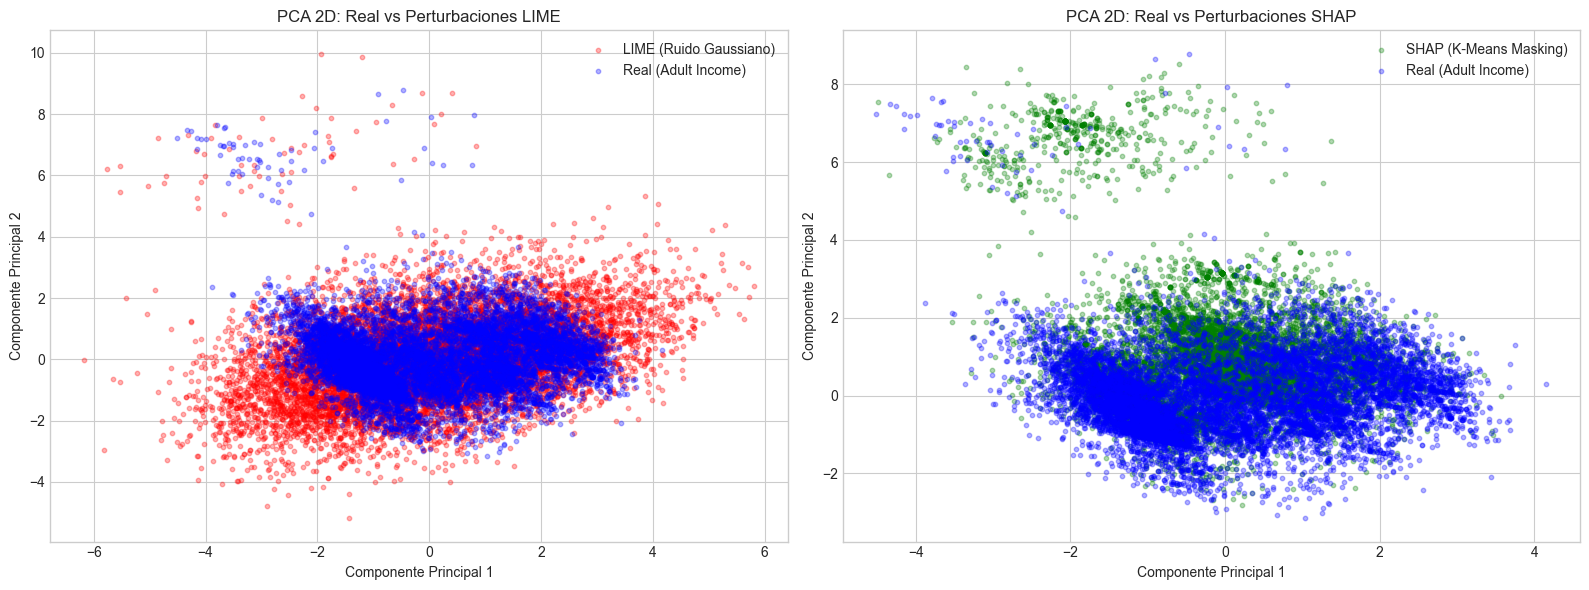

In [14]:
# PCA sobre datos reales y perturbados para visualizar la separación entre distribuciones.
# El escalado se ajusta sobre los datos reales y se aplica al resto para no filtrar
# información de las perturbaciones en la transformación.
scaler = StandardScaler()
X_real_scaled = scaler.fit_transform(X_real_sample)
X_lime_scaled = scaler.transform(X_lime_simulado)
X_shap_scaled = scaler.transform(X_shap_simulado)

# PCA ajustado sobre datos reales: las perturbaciones se proyectan en el mismo espacio
pca = PCA(n_components=2, random_state=SEED)
pca_real = pca.fit_transform(X_real_scaled)
pca_lime = pca.transform(X_lime_scaled)
pca_shap = pca.transform(X_shap_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
alpha_val, punto_size = 0.3, 10

axes[0].scatter(pca_lime[:, 0], pca_lime[:, 1],
                alpha=alpha_val, s=punto_size, color='red', label='LIME (Ruido Gaussiano)')
axes[0].scatter(pca_real[:, 0], pca_real[:, 1],
                alpha=alpha_val, s=punto_size, color='blue', label='Real (Adult Income)')
axes[0].set_title('PCA 2D: Real vs Perturbaciones LIME')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')
axes[0].legend()

axes[1].scatter(pca_shap[:, 0], pca_shap[:, 1],
                alpha=alpha_val, s=punto_size, color='green', label='SHAP (K-Means Masking)')
axes[1].scatter(pca_real[:, 0], pca_real[:, 1],
                alpha=alpha_val, s=punto_size, color='blue', label='Real (Adult Income)')
axes[1].set_title('PCA 2D: Real vs Perturbaciones SHAP')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')
axes[1].legend()

plt.tight_layout()
plt.show()


Estos gráficos PCA nos permiten ver cómo las perturbaciones de LIME y SHAP se distribuyen de forma diferente entre sí, y también respecto a los datos reales. En el gráfico izquierdo, las perturbaciones de LIME (rojo) forman una nube
notablemente más dispersa que los datos reales (azul), ya que al ignorar las correlaciones entre
variables, LIME genera instancias que ocupan regiones del espacio de features
que no existen en el dataset real. Esto explica el
F1=1.0 obtenido por el detector, que puede aprender una frontera de decisión entre los datos de forma sencilla, debido a la diferencia entre ellos.

A la derecha, las perturbaciones de SHAP (verde) se solapan bastante más con los datos reales (azul) que en el caso anterior, especialmente en la región central donde se concentran la mayoría de los datos. Al sustituir solo los valores de algunas features por el del centroide, el resto manetienen sus valores reales, lo que hace que las perturbaciones se parezcan más a la distribución orginal, de ahí que el detector de SHAP no alcance unas métricas perfectas y tenga alguna dificultad más para separar.

En conclusión, estos gráficos demuestran la necesidad de entrenar un detector diferente para cada método de explicación, ya que una única frontera de decisión para ambos no sería igual de efectiva a la hora de detectar perturbaciones.

## 5. Clasificador adversario $\psi$

Tras haber entrenado todos los modelos que necesitamos (modelos sesgado e inocuo y detectores de perturbaciones) para construir nuestro sistema capaz de engañar a métodos de explicación como LIME y SHAP, el último paso es unirlos en un sistema adversario que los integre. Siguiendo la idea del paper original, el objetivo es detectar si el dato introducido al sistema se corresponde con una persona real o ha sido generado sintéticamente y, en función del resultado, enviarlo al modelo sesgado o al modelo inocuo según corresponda.


$$\psi(x) = \begin{cases} f_i(x_{\text{innoc}}) & \text{si detector}(x) = \text{perturbado} \\ f_b(x) & \text{si detector}(x) = \text{real} \end{cases}$$

Sobre esta idea propuesta en el paper original, hemos decidido que como en una auditoría no sabemos el método de explicación que se va a utilizar en cada momento, en lugar de construir un sistema que solo utilice el detector de LIME y otro que solo utilice el de SHAP, podría ser interesante combinarlos para hacer a nuestro sistema agnóstico a cualquiera de estos dos métodos. Para ello, se aplica una lógica OR, de forma que si cualquiera de los detectores sospecha que la entrada es una perturbación se envía al modelo inocuo ($f_i$).

A nivel de implementación, la función `_is_perturbed` usa `predict_proba[:, 0]` (probabilidad de ser real) con umbral 0.5, de forma que si la confianza del detector en que la entrada es un dato real cae por debajo del umbral, este se envía al modelo inocuo ($f_i$). Una limitación de la lógica OR es que puede aumentar la tasa de falsos positivos (datos reales clasificados como perturbaciones), lo que podría reducir la fidelidad en casos límite.

In [15]:
class RobustAdversarialModel:
    """
    Clasificador adversarial que combina un modelo sesgado (f) y uno inocuo (ψ)
    mediante detección OOD. Acepta múltiples detectores y aplica lógica OR:
    si cualquiera sospecha que la entrada es una perturbación, se enruta a ψ.
    Esto lo hace agnóstico al método de explicación que use el auditor.
    """

    def __init__(self, clf_biased, clf_innocuous, detectors,
                 innocuous_idx, threshold=0.5):
        self.clf_biased    = clf_biased
        self.clf_innocuous = clf_innocuous
        self.detectors     = detectors if isinstance(detectors, (list, tuple)) else [detectors]
        self.innocuous_idx = innocuous_idx
        self.threshold     = threshold
        self.n_real        = 0
        self.n_perturbed   = 0

    def _is_perturbed(self, X):
        """
        Devuelve una máscara booleana indicando qué instancias se consideran
        perturbaciones. Usa predict_proba[:, 0] (P(Real)) — si cae por debajo
        del umbral en cualquier detector, la instancia se enruta a ψ (OR lógico).
        """
        is_pert = np.zeros(len(X), dtype=bool)
        for detector in self.detectors:
            is_pert |= (detector.predict_proba(X)[:, 0] < self.threshold)
        return is_pert

    def predict_proba(self, X):
        X = np.atleast_2d(X)
        out = np.zeros((len(X), 2))
        is_pert = self._is_perturbed(X)

        if is_pert.any():
            out[is_pert] = self.clf_innocuous.predict_proba(
                X[is_pert][:, self.innocuous_idx])
            self.n_perturbed += is_pert.sum()

        if (~is_pert).any():
            out[~is_pert] = self.clf_biased.predict_proba(X[~is_pert])
            self.n_real += (~is_pert).sum()

        return out

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

    def reset(self):
        """Reinicia los contadores de enrutamiento."""
        self.n_real = self.n_perturbed = 0

    def routing_report(self):
        """Muestra qué proporción de llamadas fue enrutada a cada modelo."""
        total = self.n_real + self.n_perturbed
        if total == 0:
            print("Sin llamadas registradas.")
            return
        print(f"  → f_biased (real)      : {self.n_real:6,d}  ({self.n_real/total:.1%})")
        print(f"  → ψ_innocuous (OOD)    : {self.n_perturbed:6,d}  ({self.n_perturbed/total:.1%})")

In [16]:
# El adversario combina ambos detectores — cualquiera puede activar el enrutamiento a ψ
adv_master = RobustAdversarialModel(
    clf_biased=clf_biased,
    clf_innocuous=clf_innocuous,
    detectors=[detector_lime, detector_shap],
    innocuous_idx=innoc_idx,
    threshold=0.5
)

# Rendimiento sobre datos reales de test: el adversario debe mantener
# métricas comparables a f_biased para no ser detectable por el auditor
adv_master.reset()
acc_adv = accuracy_score(y_test, adv_master.predict(X_test_all))
auc_adv = roc_auc_score(y_test, adv_master.predict_proba(X_test_all)[:, 1])

print("=== Rendimiento en TEST (datos reales) ===")
print(f"  f_biased    — Acc: {acc_b:.4f} | AUC: {auc_b:.4f}")
print(f"  f_innocuous — Acc: {acc_i:.4f} | AUC: {auc_i:.4f}")
print(f"  ψ adversario — Acc: {acc_adv:.4f} | AUC: {auc_adv:.4f}")

print("\n=== Ruteo durante evaluación en test ===")
adv_master.routing_report()

=== Rendimiento en TEST (datos reales) ===
  f_biased    — Acc: 0.8471 | AUC: 0.8364
  f_innocuous — Acc: 0.8702 | AUC: 0.9259
  ψ adversario — Acc: 0.8552 | AUC: 0.8522

=== Ruteo durante evaluación en test ===
  → f_biased (real)      : 17,272  (93.8%)
  → ψ_innocuous (OOD)    :  1,142  (6.2%)


En estos resultados podemos ver las métricas para los modelos sesgado e inocuo junto a las de todo el sistema completo. Estos confirman que nuestro clasificador adversario tiene un comportamiento similar (0.8548 de accuracy y 0.8514 de AUC) a los de `f_biased` (0.8471 / 0.8364) y `f_innocuous` (0.8702 / 0.9259), por lo que un auditor que solo comparase el rendimiento en terminos generales no detectaría una diferencia notable.

Si nos fijamos en cómo se han enrutado los datos, el 93.9% de las instancias de test se han identificado correctamente como datos reales y han sido enrutadas a `f_biased`, mientras que solo el 6.1% activa el enrutamiento al modelo inocuo. Este porcentaje se corresponde con instancias del test que los detectores OOD clasifican erróneamente como perturbaciones y, seguramente se traten de casos límite que han conseguido engañar a alguno de los detectores. En cualquier caso, este margen de error es suficientemente pequeño para que la fidelidad del adversario respecto a `f_biased` sea alta.

Un detalle relevante es que el AUC del adversario (0.8514) supera ligeramente al de `f_biased` (0.8364). Esto se debe precisamente a ese 6.1% de instancias enrutadas al modelo inocuo, que tiene un AUC de 0.9259 y predice mejor, por lo que a nivel de métricas el adversario se beneficia de sus propios errores de detección, aunque este no es el objetivo principal de construir este sistema.

## 6. Ataque adversario sobre LIME

Con todo el sistema construido, el siguiente paso es comprobar si es capaz de engañar a los métodos de explicación. El primer método con el que vamos a probar es LIME, que como mencionamos previamente, genera explicaciones locales para cada predicción construyendo un modelo lineal alrededor de la instancia que se quiere explicar. Para ello, LIME genera instancias artificiales perturbando aleatoriamente los valores de la instancia original, observa cómo cambia la predicción del modelo ante esas perturbaciones y ajusta una regresión lineal ponderada donde las instancias más cercanas al punto original tienen mayor peso. Los coeficientes de esa regresión se corresponden con la importancia que da LIME a cada feature en la explicación final, de forma que un coeficiente alto indica que pequeñas variaciones en esa feature producen grandes cambios en la predicción y, por tanto, es importante para el modelo a la hora de decidir.

Para ello, lo que hemos hecho ha sido instanciar un explicador a partir de las instancias del conjunto de entrenamiento y generar explicaciones para 500 instancias, número que consideramos adecuado para que los resultados sean representativos sin que el ataque tarde demasiado tiempo en realizarse. Además, al seleccionar estas instancias, nos hemos asegurado de que los detectores no hayan sido entrenados con ellas para que no haya un data leakage que invalide el resultado de los experimentos. Estas explicaciones las generamos utilizando dos modelos, por un lado únicamente el modelo sesgado ($f_b$), que actúa como referencia para medir el sesgo visible sin ataque y, por otro, el clasificador adversarial $\psi$, que nos permitirá ver si estamos engañando al método de explicación. Igual que hacen en el paper original, para cada instancia extraemos el Top 3 features ordenadas por importancia absoluta y nos fijamos en qué posición aparecen las variables sensibles (`sex`, `race`,  `relationship`) frente a las inocuas.

La métrica principal es el porcentaje de instancias para las que alguna variable sensible ocupa el 1er puesto del ranking, donde un valor alto indica que LIME expone el sesgo y un valor cercano a 0 indica que el ataque lo ha ocultado con éxito.

Instancias de test disponibles tras filtrado: 7127
Solapamiento tras filtrado: 0

Generando explicaciones LIME — modelo sesgado (500 instancias)...
  500/500
✓ 3.3s
Generando explicaciones LIME — modelo adversarial (500 instancias)...
  500/500
✓ 28.9s


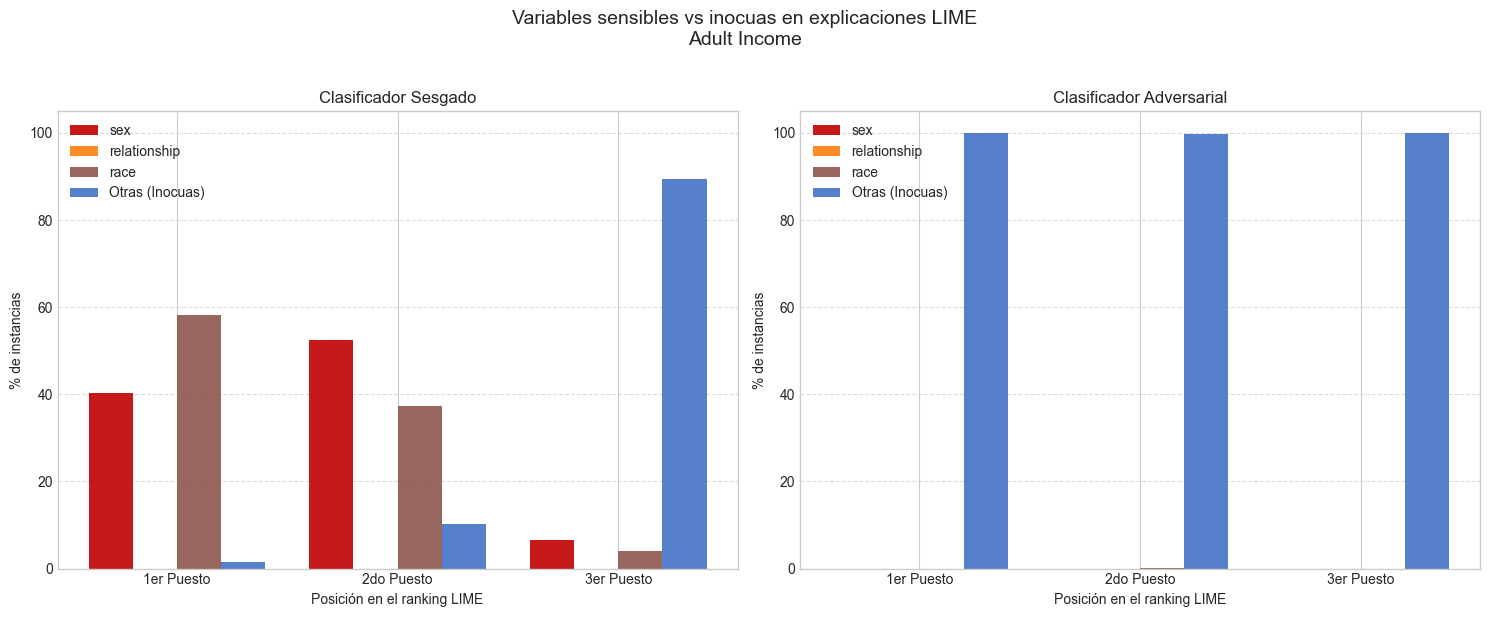


=== RESUMEN DEL ATAQUE (Top 1) ===
Variables sensibles (sex, race, relationship) en Top 1:
  Modelo sesgado     : 98.6%
  Modelo adversarial : 0.0%

Variables inocuas en Top 1:
  Modelo sesgado     : 1.4%
  Modelo adversarial : 100.0%


In [18]:
# ── Explainer LIME ─────────────────────────────────────────────────────────
# LimeTabularExplainer usa el training data para estimar las estadísticas
# de cada feature (media, std, frecuencias) con las que genera perturbaciones.
# Usamos el dataset completo de train para maximizar la precisión de esas
# estadísticas. discretize_continuous=False para obtener pesos continuos
# en lugar de rangos discretos, lo que permite comparar importancias entre
# modelos con más precisión.
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train[feature_names].values,
    feature_names=feature_names,
    class_names=['<=50K', '>50K'],
    discretize_continuous=False,
    random_state=SEED
)

def get_lime_top3(explainer, predict_fn, X_instances, num_samples=3000):
    top3_list = []
    for i, inst in enumerate(X_instances):
        exp = explainer.explain_instance(
            inst, predict_fn,
            num_features=len(feature_names),
            num_samples=num_samples
        )
        sorted_feats = sorted(exp.as_list(), key=lambda x: abs(x[1]), reverse=True)
        top3_list.append([f[0] for f in sorted_feats[:3]])
        if (i+1) % 10 == 0: print(f"  {i+1}/{len(X_instances)}", end='\r')
    return top3_list


# ── Selección de instancias de evaluación ──────────────────────────────────
# Excluimos las instancias de test que el detector OOD vio durante su
# entrenamiento (X_real_sample ⊂ X_train) para evitar data leakage
# en la evaluación — el detector no debe haber visto las instancias
# que intentamos explicar.
N_LIME = 500
X_test_arr = X_test[feature_names].values
train_tuples = set(map(tuple, X_train[feature_names].values))
mask_limpia = np.array([tuple(x) not in train_tuples for x in X_test_arr])
X_test_limpio = X_test_arr[mask_limpia]

print(f"Instancias de test disponibles tras filtrado: {len(X_test_limpio)}")

idx_eval = np.random.choice(len(X_test_limpio), N_LIME, replace=False)
X_eval = X_test_limpio[idx_eval]

# Verificación
overlap = set(map(tuple, X_eval)) & train_tuples
print(f"Solapamiento tras filtrado: {len(overlap)}")  # debe ser 0


# ── Generación de explicaciones ────────────────────────────────────────────
print(f"\nGenerando explicaciones LIME — modelo sesgado ({N_LIME} instancias)...")
t0 = time.time()
top3_f_lime = get_lime_top3(lime_explainer, clf_biased.predict_proba, X_eval)
print(f"\n✓ {time.time()-t0:.1f}s")

print(f"Generando explicaciones LIME — modelo adversarial ({N_LIME} instancias)...")
t0 = time.time()
top3_e_lime = get_lime_top3(lime_explainer, adv_master.predict_proba, X_eval)
print(f"\n✓ {time.time()-t0:.1f}s")


# ── Estadísticas por feature ───────────────────────────────────────────────
# Para cada instancia, rastreamos en qué posición del ranking aparece
# cada variable sensible y cuántas veces las features inocuas ocupan ese hueco.
def compute_comprehensive_stats(top3_list, sensitive_feats):
    n = len(top3_list)
    stats = {feat: [0, 0, 0] for feat in sensitive_feats}
    stats['Otras (Inocuas)'] = [0, 0, 0]

    for top3 in top3_list:
        for rank, feat_str in enumerate(top3):
            matched = False
            for s_feat in sensitive_feats:
                if s_feat in feat_str:
                    stats[s_feat][rank] += 1
                    matched = True
                    break
            if not matched:
                stats['Otras (Inocuas)'][rank] += 1

    for k in stats:
        stats[k] = [v / n * 100 for v in stats[k]]
    return stats

def sumar_sensibles(stats, rank_idx):
    """Suma el % de instancias donde cualquier feature sensible aparece en un rank dado."""
    return sum(stats[f][rank_idx] for f in variables_vigiladas)


variables_vigiladas = ['sex', 'relationship', 'race']
stats_f_multi = compute_comprehensive_stats(top3_f_lime, variables_vigiladas)
stats_e_multi = compute_comprehensive_stats(top3_e_lime, variables_vigiladas)


# ── Visualización ──────────────────────────────────────────────────────────
colors_bar = {
    'sex':              '#C00000',
    'relationship':     '#FF7F0E',
    'race':             '#8C564B',
    'Otras (Inocuas)':  '#4472C4'
}
ranks = ['1er Puesto', '2do Puesto', '3er Puesto']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (stats, title) in zip(axes, [
    (stats_f_multi, 'Clasificador Sesgado'),
    (stats_e_multi, 'Clasificador Adversarial')
]):
    x = np.arange(3)
    for i, (feat, color) in enumerate(colors_bar.items()):
        ax.bar(x + i*0.2, stats[feat], 0.2, label=feat, color=color, alpha=0.9)
    ax.set_xticks(x + 0.3)
    ax.set_xticklabels(ranks)
    ax.set_xlabel('Posición en el ranking LIME')
    ax.set_ylabel('% de instancias')
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, 105)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle(
    'Variables sensibles vs inocuas en explicaciones LIME\nAdult Income',
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()


# ── Resumen numérico ───────────────────────────────────────────────────────
print("\n=== RESUMEN DEL ATAQUE (Top 1) ===")
print(f"Variables sensibles (sex, race, relationship) en Top 1:")
print(f"  Modelo sesgado     : {sumar_sensibles(stats_f_multi, 0):.1f}%")
print(f"  Modelo adversarial : {sumar_sensibles(stats_e_multi, 0):.1f}%")
print(f"\nVariables inocuas en Top 1:")
print(f"  Modelo sesgado     : {stats_f_multi['Otras (Inocuas)'][0]:.1f}%")
print(f"  Modelo adversarial : {stats_e_multi['Otras (Inocuas)'][0]:.1f}%")

Tras ejecutar el ataque, vemos claramente que el ataque ha sido un éxito y hemos engañado a LIME totalmente. Utilizando únicamente el modelo sesgado, las variables sensibles son las que aparecen en los primeros puestos del ranking, concretamente `race` aparece en el primer puesto para casi el 60% de las instancias y `sex` para más del 40%. `relationship` apenas aparece de forma independiente porque su señal queda absorbida por `sex` y `race`, ya que el modelo sesgado usa directamente los atributos protegidos y no necesita recurrir al proxy. Las variables inocuas solo logran ser las variables más importantes para la decisión en muy pocos casos, confirmando que un auditor que usara LIME sobre el modelo sesgado ($f_b$) detectaría el sesgo de forma inmediata.

Tras aplicar el scaffolding adversarial, el resultado cambia completamente, ya que las variables sensibles desaparecen por completo del ranking en las 500 instancias evaluadas, y las features inocuas ocupan el 100% de las tres primeras posiciones en todas las instancias. Por ello, este experimento demuestra que hemos sido capaces de engañar completamente a LIME, lo que encaja con el comportamiento tan bueno que había tenido nuestro detector OOD de LIME (F1=1.0), que está siendo capaz de distinguir los datos reales de las perturbaciones sin ninguna dificultad para enviárselos al modelo inocuo ($f_i$) y generar explicaciones no sesgadas.

La conlusión de esta parte del exprimento es que un un auditor que usara exclusivamente LIME para inspeccionar nuestro modelo adversarial obtendría explicaciones centradas en `capital_gain`, `education_num` o `marital_status`, sin ninguna señal de discriminación por raza o sexo, a pesar de que el modelo discrimina por estos atributos en el 93.9% de sus predicciones reales.

## 7. Ataque adversario sobre SHAP (KernelExplainer)

En esta sección vamos a intentar realizar el mismo ataque pero en este caso sobre SHAP. De esta forma podremos ver si nuestro sistema también es capaz de engañarlo y hacer una comparativa final entre ambos. A diferencia de LIME, SHAP basa sus explicaciones en la teoría de juegos cooperativos, de forma que el valor de Shapley de una feature mide su contribución marginal promedio sobre todas las posibles combinaciones de features.

Para simular este ataque al método de explicación, vamos a utilizar la implementación de SHAP con KernelExplainer, que funciona sobre cualquier modelo, independientemente de su arquitectura, aunque es menos eficiente que otras implementaciones. Para generar estas perturbaciones, este método aproxima los valores de Shapley generando perturbaciones tomando un subconjunto de atributos de los datos y sustituyéndolos por el valor del centroide correspondiente calculado con K-Means (k=10 en nuestro caso) sobre el conjunto de entrenamiento. Esta diferencia en la forma de generar las perturbaciones hace que SHAP sea más robusto, puesto que valores utilizados para generar las perturbaciones son más realistas y totalmente aleatorios como ocurría en LIME.

La métrica de evaluación es la misma que en la sección anterior, es decir, el porcentaje de instancias para las que alguna variable sensible (`sex`, `race`, `relationship`) ocupa el 1er puesto del ranking de importancia, antes y después de aplicar el scaffolding adversarial.

Solapamiento con train tras filtrado: 0

Calculando SHAP — modelo sesgado (500 instancias)...
✓ 8.6s
Calculando SHAP — modelo adversarial (500 instancias)...
✓ 35.8s


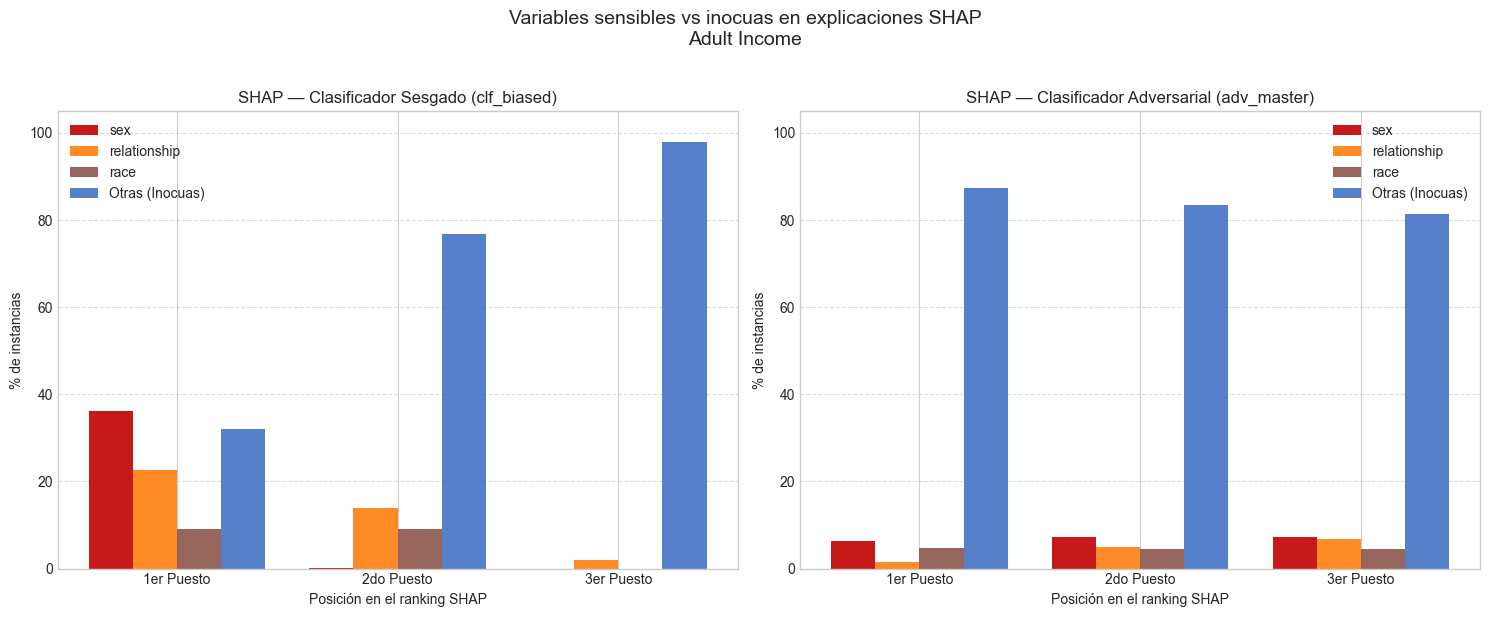


=== RESUMEN DEL ATAQUE SHAP (Top 1) ===
Variables sensibles (sex, race, relationship) en Top 1:
  Modelo sesgado     : 68.0%
  Modelo adversarial : 12.6%

Variables inocuas en Top 1:
  Modelo sesgado     : 32.0%
  Modelo adversarial : 87.4%


In [19]:
# ── Background distribution ────────────────────────────────────────────────
# Obtención de los centroides con K-Means (k=10)
X_train_arr = X_train[feature_names].values
background = shap.kmeans(X_train_arr, 10)

# ── Instancias de evaluación ───────────────────────────────────────────────
# Reutilizamos X_test_limpio (ya filtrado de leakage en la sección anterior)
# pero remuestreamos para que SHAP use instancias distintas a las de LIME,
# evitando cualquier dependencia entre los dos experimentos.
N_SHAP = 500
idx_eval_shap = np.random.choice(len(X_test_limpio), N_SHAP, replace=False)
X_eval_shap = X_test_limpio[idx_eval_shap]

overlap_shap = set(map(tuple, X_eval_shap)) & train_tuples
print(f"Solapamiento con train tras filtrado: {len(overlap_shap)}")

# ── Explainers y valores SHAP ──────────────────────────────────────────────
explainer_f = shap.KernelExplainer(clf_biased.predict_proba, background)
explainer_e = shap.KernelExplainer(adv_master.predict_proba, background)

print(f"\nCalculando SHAP — modelo sesgado ({N_SHAP} instancias)...")
t0 = time.time()
shap_values_f = explainer_f.shap_values(X_eval_shap, silent=True)
print(f"✓ {time.time()-t0:.1f}s")

print(f"Calculando SHAP — modelo adversarial ({N_SHAP} instancias)...")
t0 = time.time()
shap_values_e = explainer_e.shap_values(X_eval_shap, silent=True)
print(f"✓ {time.time()-t0:.1f}s")


# ── Extracción del Top 3 ───────────────────────────────────────────────────
def get_shap_top3(shap_vals, features):
    if isinstance(shap_vals, list):
        vals = shap_vals[1]
    elif shap_vals.ndim == 3:
        vals = shap_vals[:, :, 1]
    else:
        vals = shap_vals

    features_arr = np.array(features)
    top3_list = []
    for row in vals:
        inst_vals = np.ravel(row)
        sorted_idx = np.argsort(-np.abs(inst_vals))
        top3_list.append(features_arr[sorted_idx[:3]].tolist())
    return top3_list


top3_f_shap = get_shap_top3(shap_values_f, feature_names)
top3_e_shap = get_shap_top3(shap_values_e, feature_names)

stats_f_shap = compute_comprehensive_stats(top3_f_shap, variables_vigiladas)
stats_e_shap = compute_comprehensive_stats(top3_e_shap, variables_vigiladas)


# ── Visualización ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (stats, title) in zip(axes, [
    (stats_f_shap, 'Clasificador Sesgado (clf_biased)'),
    (stats_e_shap, 'Clasificador Adversarial (adv_master)')
]):
    x = np.arange(3)
    for i, (feat, color) in enumerate(colors_bar.items()):
        ax.bar(x + i*0.2, stats[feat], 0.2, label=feat, color=color, alpha=0.9)
    ax.set_xticks(x + 0.3)
    ax.set_xticklabels(ranks)
    ax.set_xlabel('Posición en el ranking SHAP')
    ax.set_ylabel('% de instancias')
    ax.set_title(f'SHAP — {title}')
    ax.legend()
    ax.set_ylim(0, 105)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle(
    'Variables sensibles vs inocuas en explicaciones SHAP\nAdult Income',
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()


# ── Resumen numérico ───────────────────────────────────────────────────────
print("\n=== RESUMEN DEL ATAQUE SHAP (Top 1) ===")
print(f"Variables sensibles (sex, race, relationship) en Top 1:")
print(f"  Modelo sesgado     : {sumar_sensibles(stats_f_shap, 0):.1f}%")
print(f"  Modelo adversarial : {sumar_sensibles(stats_e_shap, 0):.1f}%")
print(f"\nVariables inocuas en Top 1:")
print(f"  Modelo sesgado     : {stats_f_shap['Otras (Inocuas)'][0]:.1f}%")
print(f"  Modelo adversarial : {stats_e_shap['Otras (Inocuas)'][0]:.1f}%")


Tal y como habíamos previsto en la introducción de esta sección, SHAP es más robusto que LIME y, aunque el ataque es bastante efectivo no es tan bueno como en el caso anterior. En el modelo sesgado, las variables sensibles ocupan el 1er puesto en el 67% de las instancias, siendo `sex` la que más veces aparece. Una cosa que nos ha llamado bastante la atención es que para más de un 30% de las instancias, una feature inocua aparece en primera posición del ranking, a diferencia de lo que sucedía con LIME. Esto se debe a que SHAP exige que las importancias de todas las features sumen la diferencia entre la predicción del modelo y la predicción media de referencia, por lo que al aproximar los valores Shapley mediante muestreo, la importancia se reparte entre más features, haciendo que el sesgo no aparezca representado de forma tan clara en las explicaciones de SHAP.

Al probar el ataque sobre el sistema que hemos diseñado para engañar a los métodos de explicación, vemos que las variables sensibles solo aparecen en el primer puesto para un 12% de las instancias, mientras que en el modelo sesgado llegaban al 67%. Si nos fijamos en las tres posiciones del ranking, vemos que el ataque ha funcionado en más de un 80% de los casos pero, aquí sí se desvela un cierto sesgo, ya que hay ocasiones donde aparecen las variables sensibles, lo que podría llamar la atención de un auditor al evaluar el modelo. Estos casos donde nuestro sistema no ha sido capaz de engañar a la explicación, son aquellos en los que el detector OOD ha fallado, clasificando una perturbación como dato real y, por tanto, lo envió al modelo sesgado ($f_b$), exponiendo el sesgo del modelo discriminatorio.

## 8. Comparativa de los ataques sobre LIME y SHAP

COMPARATIVA FINAL — Adult Income
Atributos sensibles: sex, race, relationship
Método        Antes   Después   Reducción Efectividad
-----------------------------------------------------------------
LIME          98.0%      0.0%       98.0pp      100.0%
SHAP          65.6%     11.4%       54.2pp       82.6%


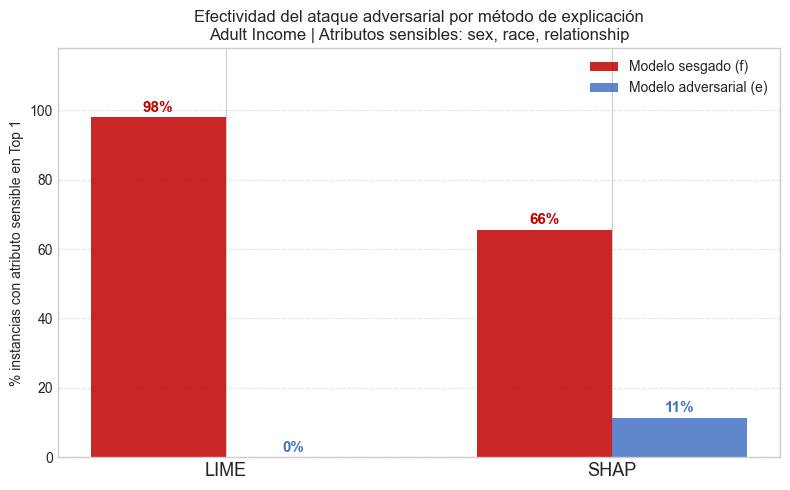

In [ ]:
# ── Métricas comparativas ──────────────────────────────────────────────────
lime_f = sumar_sensibles(stats_f_multi, 0)
lime_e = sumar_sensibles(stats_e_multi, 0)
shap_f = sumar_sensibles(stats_f_shap,  0)
shap_e = sumar_sensibles(stats_e_shap,  0)

print("="*65)
print("COMPARATIVA FINAL — Adult Income")
print("Atributos sensibles: sex, race, relationship")
print("="*65)
print(f"{'Método':<10} {'Antes':>8} {'Después':>9} {'Reducción':>11} {'Efectividad'}")
print("-"*65)
for name, before, after in [('LIME', lime_f, lime_e), ('SHAP', shap_f, shap_e)]:
    red = before - after
    eff = red / before * 100 if before > 0 else 0
    print(f"{name:<10} {before:>7.1f}% {after:>8.1f}% {red:>10.1f}pp {eff:>10.1f}%")
print("="*65)


# ── Visualización ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
methods     = ['LIME', 'SHAP']
before_vals = [lime_f, shap_f]
after_vals  = [lime_e, shap_e]
x, w        = np.arange(2), 0.35

ax.bar(x - w/2, before_vals, w, label='Modelo sesgado (f)',     color='#C00000', alpha=0.85)
ax.bar(x + w/2, after_vals,  w, label='Modelo adversarial (e)', color='#4472C4', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=13)
ax.set_ylabel('% instancias con atributo sensible en Top 1')
ax.set_title(
    'Efectividad del ataque adversarial por método de explicación\n'
    'Adult Income | Atributos sensibles: sex, race, relationship'
)
ax.legend()
ax.set_ylim(0, max(max(before_vals), max(after_vals)) + 20)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for xi, (b, a) in zip(x, zip(before_vals, after_vals)):
    ax.text(xi - w/2, b + 1.5, f'{b:.0f}%', ha='center', fontsize=11,
            fontweight='bold', color='#C00000')
    ax.text(xi + w/2, a + 1.5, f'{a:.0f}%', ha='center', fontsize=11,
            fontweight='bold', color='#4472C4')

plt.tight_layout()
plt.show()

En esta gráfica comparativa final de la efectividad de los ataques podemos ver la diferencia de vulnerabilidad entre ambos métodos de explicación. En ella podemos ver que hemos engañado a LIME casi por completo, ya que las variables sensibles pasan de aparecer en el Top 1 en el 98% de las instancias a no aparecer cuando generamos explicaciones sobre nuestro sistema diseñado para engañar. Lo mismo ocurre para la segunda y tercera posición, por lo que un auditor que utilizará LIME para inspecionar nuestro modelo adversario ($\psi$), no encontraría ningún indicio de discriminación, a pesar de que el modelo discrimina por raza y sexo en la mayoría de sus predicciones reales.

Respecto a SHAP, vemos que el ataque logra ocultar el sesgo para la mayoría de las instancias, pasando de un 67% en el sesgado ($f_b$) a un 12% en el modelo adversario ($\psi$). Por tanto, aunque es una reducción importante, ese 12% permitiría a un auditor comenzar a sospechar de que hay algo raro con nuestro sistema. Estas instancias que no consiguen engañar al método de explicación son aquellas en las que nuestro detector OOD ha fallado, clasificándolas como un dato real cuando no lo eran, lo que es una consecuencia del F1=0.892 del detector de SHAP, que no era infalible, frente al F1=1.0 del de LIME.

Como hemos comentado anteriormente y de forma individual para cada método, estos se comportan de forma distinta a la hora de generar las perturbaciones. En el caso de LIME, se introduce ruido sin tener en cuenta las correlaciones, mientras que en SHAP se reemplazan features con los valores de referencia, dando lugar a perturbaciones más realistas y difíciles de separar de los datos reales. Esta diferencia es lo que hace vulnerables a estos métodos, especialmente a LIME, que es bastante fácil de engañar.

Los resultados de este experimento reflejan que, en una situación real (como la concesión de un préstamo o la aplicación a un puesto de trabajo), alguien con malas intenciones podría poner en funcionamiento modelos discriminatorios y, si un auditor se limita a utilizar estos métodos de explicación con esta configuración sencilla de los mismos, podría ser engañado y permitir que un modelo estuviese en funcionamiento discriminando a ciertos grupos de personas o minorías.

## 9. Influencia del detector en el ataque

Hasta este punto hemos comprobado la efectividad de los ataques sobre los métodos de explicación LIME y SHAP utilizando los detectores que entrenamos al comienzo del notebook. Sin embargo, como ya planteamos antes, la clave de este engaño está en cómo estos métodos generan las perturbaciones y en cómo de buenos son los detectores a la hora de identificarlas. Por ello, siguiendo la idea que plantean los autores del paper original, veremos cómo varía la cantidad de sesgo visible en las explicaciones de LIME y SHAP a medida que cambiamos la complejidad del clasificador OOD.

Para ello, entrenamos varios detectores con distintas configuraciones de Random Forest, variando el número de estimadores y la profundidad máxima, desde modelos muy simples hasta el utilizado en el ataque principal. Para cada configuración mediremos el F1 del detector y el porcentaje de instancias en las que una variable sensible aparece la primera posición del ranking de explicaciones.

Solapamiento eval con train: 0
Evaluando 5 configuraciones...

[n_est=5, max_depth=2]
  F1  — LIME: 0.940 | SHAP: 0.758
  Sesgo visible — LIME: 0.0% | SHAP: 40.0%
  Tiempo: 13.1s

[n_est=10, max_depth=3]
  F1  — LIME: 0.999 | SHAP: 0.801
  Sesgo visible — LIME: 0.0% | SHAP: 42.0%
  Tiempo: 13.1s

[n_est=20, max_depth=5]
  F1  — LIME: 1.000 | SHAP: 0.847
  Sesgo visible — LIME: 0.0% | SHAP: 39.0%
  Tiempo: 12.9s

[n_est=50, max_depth=8]
  F1  — LIME: 1.000 | SHAP: 0.887
  Sesgo visible — LIME: 0.0% | SHAP: 31.0%
  Tiempo: 13.4s

[n_est=100, max_depth=None]
  F1  — LIME: 1.000 | SHAP: 0.982
  Sesgo visible — LIME: 0.0% | SHAP: 6.0%
  Tiempo: 14.0s

✓ Análisis completado


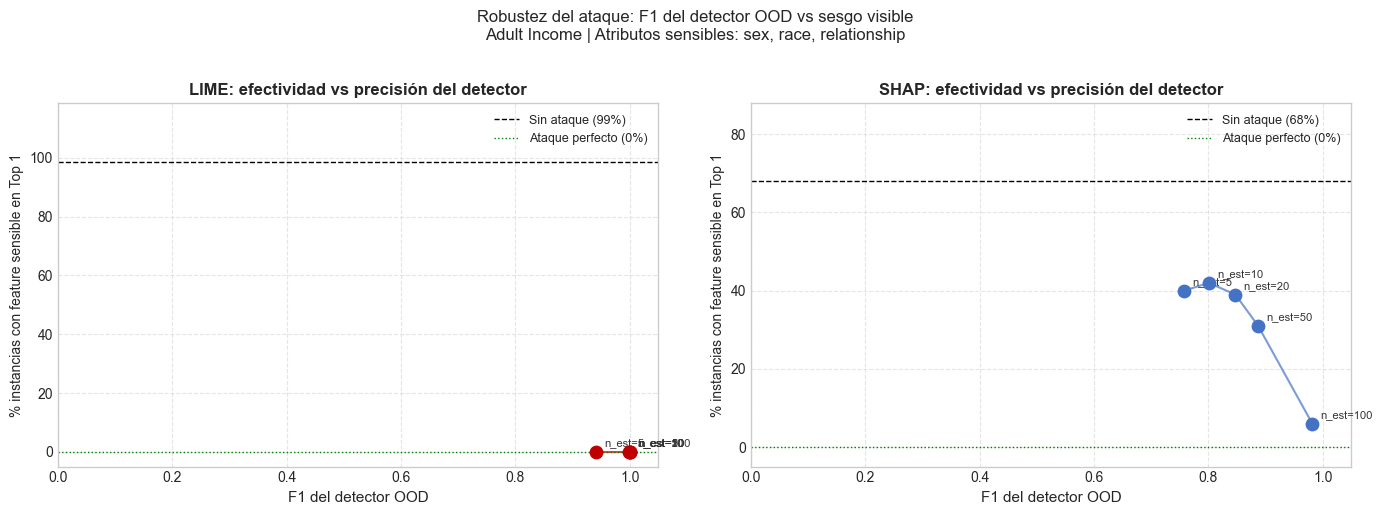

In [22]:
# ── Configuraciones del detector OOD ──────────────────────────────────────
OOD_CONFIGS = [
    (5,   2),
    (10,  3),
    (20,  5),
    (50,  8),
    (100, None),
]

N_OOD_CURVE  = 5000
N_EVAL_CURVE = 100

# Datos base fijos para todos los detectores
X_ood_base_df = X_train[feature_names].sample(n=N_OOD_CURVE, random_state=SEED)

X_pert_lime_curve = generar_perturbaciones_lime(X_ood_base_df)
X_pert_shap_curve = generar_perturbaciones_shap(X_ood_base_df)

idx_curve    = np.random.choice(len(X_test_limpio), N_EVAL_CURVE, replace=False)
X_eval_curve = X_test_limpio[idx_curve]
print(f"Solapamiento eval con train: "
      f"{len(set(map(tuple, X_eval_curve)) & train_tuples)}")

background_curve = shap.kmeans(X_train[feature_names].values[:3000], 10)


# ── Función de medición ────────────────────────────────────────────────────
def medir_efectividad_curva(det_lime, det_shap, X_eval, background):
    adv_tmp = RobustAdversarialModel(
        clf_biased=clf_biased,
        clf_innocuous=clf_innocuous,
        detectors=[det_lime, det_shap],
        innocuous_idx=innoc_idx,
        threshold=0.5
    )

    # LIME
    top3_lime  = get_lime_top3(lime_explainer, adv_tmp.predict_proba,
                               X_eval, num_samples=1000)
    stats_lime = compute_comprehensive_stats(top3_lime, variables_vigiladas)
    pct_lime   = sumar_sensibles(stats_lime, 0)

    # SHAP
    sv         = shap.KernelExplainer(
                     adv_tmp.predict_proba, background
                 ).shap_values(X_eval, nsamples=75, silent=True)
    top3_shap  = get_shap_top3(sv, feature_names)
    stats_shap = compute_comprehensive_stats(top3_shap, variables_vigiladas)
    pct_shap   = sumar_sensibles(stats_shap, 0)

    return pct_lime, pct_shap

resultados_curva = []

print(f"Evaluando {len(OOD_CONFIGS)} configuraciones...\n")
for n_est, max_d in OOD_CONFIGS:
    t0    = time.time()
    label = f"n_est={n_est}, max_depth={max_d}"

    # Detector LIME
    X_ood_l = pd.concat([X_ood_base_df, X_pert_lime_curve], ignore_index=True)
    y_ood_l = np.array([0]*N_OOD_CURVE + [1]*N_OOD_CURVE)
    det_l   = RandomForestClassifier(n_estimators=n_est, max_depth=max_d,
                                     random_state=SEED, n_jobs=-1)
    det_l.fit(X_ood_l, y_ood_l)
    f1_l = f1_score(y_ood_l, det_l.predict(X_ood_l))

    # Detector SHAP
    X_ood_s = pd.concat([X_ood_base_df, X_pert_shap_curve], ignore_index=True)
    y_ood_s = np.array([0]*N_OOD_CURVE + [1]*N_OOD_CURVE)
    det_s   = RandomForestClassifier(n_estimators=n_est, max_depth=max_d,
                                     random_state=SEED, n_jobs=-1)
    det_s.fit(X_ood_s, y_ood_s)
    f1_s = f1_score(y_ood_s, det_s.predict(X_ood_s))

    pct_l, pct_s = medir_efectividad_curva(det_l, det_s,
                                            X_eval_curve, background_curve)

    resultados_curva.append({
        'config': label,
        'f1_lime': f1_l, 'f1_shap': f1_s,
        'pct_lime': pct_l, 'pct_shap': pct_s
    })

    print(f"[{label}]")
    print(f"  F1  — LIME: {f1_l:.3f} | SHAP: {f1_s:.3f}")
    print(f"  Sesgo visible — LIME: {pct_l:.1f}% | SHAP: {pct_s:.1f}%")
    print(f"  Tiempo: {time.time()-t0:.1f}s\n")

print("✓ Análisis completado")


# ── Visualización ──────────────────────────────────────────────────────────
ref_lime = sumar_sensibles(stats_f_multi, 0)
ref_shap = sumar_sensibles(stats_f_shap,  0)

f1_limes  = [r['f1_lime']  for r in resultados_curva]
f1_shaps  = [r['f1_shap']  for r in resultados_curva]
pct_limes = [r['pct_lime'] for r in resultados_curva]
pct_shaps = [r['pct_shap'] for r in resultados_curva]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (f1s, pcts, ref, metodo, color) in zip(axes, [
    (f1_limes, pct_limes, ref_lime, 'LIME', '#C00000'),
    (f1_shaps, pct_shaps, ref_shap, 'SHAP', '#4472C4'),
]):
    ax.scatter(f1s, pcts, color=color, s=80, zorder=5)
    ax.plot(f1s, pcts, color=color, linewidth=1.5, alpha=0.7)

    for f1, pct, r in zip(f1s, pcts, resultados_curva):
        ax.annotate(r['config'].split(',')[0],
                    (f1, pct), textcoords='offset points',
                    xytext=(6, 4), fontsize=8, color='#333333')

    ax.axhline(ref, color='black', linestyle='--', linewidth=1,
               label=f'Sin ataque ({ref:.0f}%)')
    ax.axhline(0, color='green', linestyle=':', linewidth=1,
               label='Ataque perfecto (0%)')

    ax.set_xlabel('F1 del detector OOD', fontsize=11)
    ax.set_ylabel('% instancias con feature sensible en Top 1', fontsize=10)
    ax.set_title(f'{metodo}: efectividad vs precisión del detector',
                 fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.set_ylim(-5, ref + 20)
    ax.legend(fontsize=9)
    ax.grid(axis='both', linestyle='--', alpha=0.5)

plt.suptitle(
    'Robustez del ataque: F1 del detector OOD vs sesgo visible\n'
    'Adult Income | Atributos sensibles: sex, race, relationship',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('f1_vs_efectividad.png', dpi=150, bbox_inches='tight')
plt.show()

En el gráfico de la izquierda, correspondiente a LIME, todos los puntos aparecen en la esquina inferior derecha, ya que hasta el clasificador más simple (n_est=5, max_depth=2) alcanza un F1 superior a 0.9 y el sesgo no se revela en prácticamente ninguna instancia. Esto confirma que las perturbaciones generadas por la versión estándar de LIME se pueden separar tan fácilmente de los datos reales que hasta un Random Forest muy sencillo puede aprender una frontera de decisión bastante efectiva.

Si nos fijamos en los resultados para SHAP, sí podemos ver que a medida que aumenta la efectividad del detector, el sesgo es visible cada vez en un porcentaje menor de instancias. En este caso con n_est=5 y max_depth=2, el sesgo se revela en un 40% de las instancias aproximadamente y, a medida que aumenta la complejidad del clasificador, este porcentaje se reduce hasta el 7% con n_est=100 y sin limitar la profundidad. Esto refleja que, con un clasificador lo suficientemente bueno, cada vez se revela menos sesgo, haciendo que el ataque sea más efectivo.

## 10. Estrategias de defensa al utilizar LIME

Los resultados de las secciones anteriores demostraron que LIME en su versión estándar es vulnerable a este tipo de ataques debido a la forma en la que genera las perturbaciones utilizadas para obtener la explicación. Una posible defensa para evitar este tipo de engaños sería modificar cómo LIME genera su vecindario local para que las perturbaciones sean más difíciles de distinguir de datos reales, logrando así confundir al detector.

Nosotros vamos a explorar dos estrategias de defensa diferentes:

- **LIME con vecinos reales (KNN):** en lugar de generar perturbaciones sintéticas, buscaremos las K instancias del conjunto de entrenamiento más cercanas a la instancia que queremos explicar y construiremos el modelo lineal local sobre ellas.

- **LIME con correlaciones multivariantes:** en este caso sí generaremos perturbaciones sintéticas pero teniendo en cuenta las correlaciones entre features. Lo que hace este método es calcular la matriz de covarianza Σ del conjunto de entrenamiento, que tiene en cuenta tanto la varianza individual de cada atributo como las correlaciones entre ellos, en nuestro caso, respetaría la de -0.62 que existe entre `sex` y `relationship`. Posteriormente, muestrea el vecindario de la instancia a explicar de una gaussiana distribución multivariante N(x, Σ·α), donde x es la instancia original y α es un factor de escala que controla el tamaño del vecindario, dando como resultado perturbaciones que las correlaciones del dataset original y, por tanto, son mucho más difíciles de detectar por nuestro sistema.

En el caso de que alguna de estas estrategias de defensa consiga que los detectores consideren que no son un dato procedente de un método de explicación, lo enrutarían hacia el modelo sesgado, revelándolo en las explicaciones y demostrando que estas son unas versiones más robustas respecto a la versión estándar de LIME.

Inicializando explicadores robustos...
Auditando con LIME Vecinos Reales (500 instancias)...
✓ 7.4s
Ruteo LIME vecinos reales:
  → f_biased (real)      : 96,013  (96.0%)
  → ψ_innocuous (OOD)    :  3,987  (4.0%)
Auditando con LIME Correlación Multivariante (500 instancias)...
✓ 11.7s
Ruteo LIME correlación multivariante:
  → f_biased (real)      : 215,544  (43.1%)
  → ψ_innocuous (OOD)    : 284,456  (56.9%)


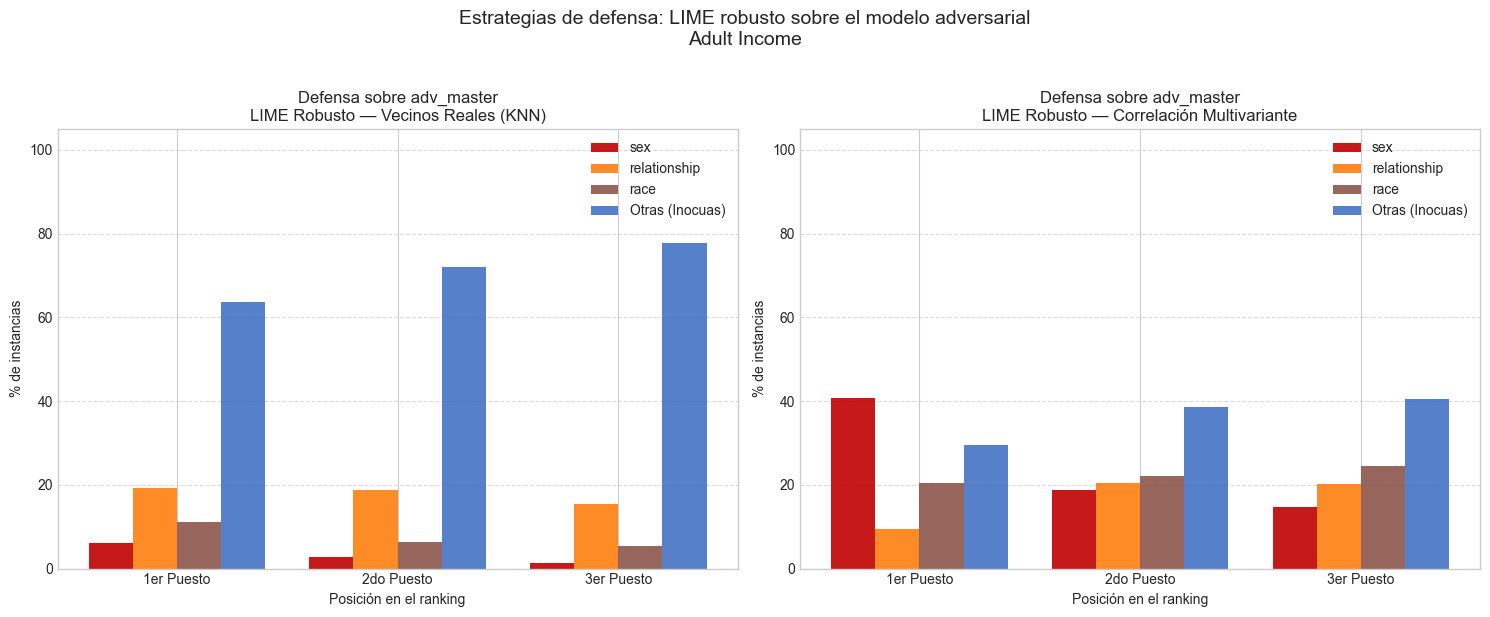


=== RESUMEN DE LA DEFENSA (Top 1) ===
Método                                     Sensibles en Top 1
--------------------------------------------------------------
LIME estándar (engañado)                                 0.0%
LIME robusto — vecinos reales                           36.4%
LIME robusto — correlación multivariante                70.6%


In [ ]:
# ── Defensas: explicadores LIME robustos ───────────────────────────────────

class LimeRealNeighborhood:
    """
    Sustituye las perturbaciones sintéticas de LIME por los K vecinos más
    cercanos reales del training set. Al usar instancias que el OOD
    classifier vio en entrenamiento, no puede detectarlas como perturbaciones.
    """
    def __init__(self, training_data, feature_names, model_predict_proba, k_neighbors=200):
        self.training_data   = training_data
        self.feature_names   = feature_names
        self.predict_fn      = model_predict_proba
        self.k               = k_neighbors
        self.scaler          = StandardScaler()
        self.training_scaled = self.scaler.fit_transform(training_data)

    def explain(self, instance, kernel_width=None):
        instance_scaled  = self.scaler.transform([instance])[0]
        distances        = cdist([instance_scaled], self.training_scaled, metric='euclidean')[0]
        nearest_idx      = np.argsort(distances)[:self.k]
        neighbors        = self.training_data[nearest_idx]
        neighbor_dist    = distances[nearest_idx]

        if kernel_width is None:
            kernel_width = np.sqrt(len(self.feature_names)) * 0.75
        weights = np.exp(-(neighbor_dist ** 2) / (kernel_width ** 2))

        probas      = self.predict_fn(neighbors)[:, 1]
        local_model = Ridge(alpha=1.0)
        local_model.fit(neighbors, probas, sample_weight=weights)

        return {'coefficients': dict(zip(self.feature_names, local_model.coef_))}


class LimeCorrelationAware:
    """
    Genera perturbaciones muestreando de N(x, Σ·α), donde Σ es la matriz
    de covarianza del training set. Respeta las correlaciones entre features,
    produciendo instancias más realistas que el ruido gaussiano independiente.
    """
    def __init__(self, training_data, feature_names, model_predict_proba):
        self.training_data   = training_data
        self.feature_names   = feature_names
        self.predict_fn      = model_predict_proba
        self.scaler          = StandardScaler()
        self.training_scaled = self.scaler.fit_transform(training_data)
        self.cov_matrix      = np.cov(self.training_scaled, rowvar=False)

    def explain(self, instance, n_samples=1000, perturbation_scale=0.5, kernel_width=None):
        instance_scaled      = self.scaler.transform([instance])[0]
        perturbations_scaled = np.random.multivariate_normal(
            mean=instance_scaled,
            cov=self.cov_matrix * perturbation_scale,
            size=n_samples
        )
        neighbors = self.scaler.inverse_transform(perturbations_scaled)

        # Clip al rango real y redondeo para variables enteras (LabelEncoded)
        for j in range(len(self.feature_names)):
            col_min = self.training_data[:, j].min()
            col_max = self.training_data[:, j].max()
            if np.all(self.training_data[:, j] == np.floor(self.training_data[:, j])):
                neighbors[:, j] = np.round(neighbors[:, j])
            neighbors[:, j] = neighbors[:, j].clip(col_min, col_max)

        distances = cdist([instance_scaled], self.scaler.transform(neighbors), metric='euclidean')[0]
        if kernel_width is None:
            kernel_width = np.sqrt(len(self.feature_names)) * 0.75
        weights = np.exp(-(distances ** 2) / (kernel_width ** 2))

        probas      = self.predict_fn(neighbors)[:, 1]
        local_model = Ridge(alpha=1.0)
        local_model.fit(neighbors, probas, sample_weight=weights)

        return {'coefficients': dict(zip(self.feature_names, local_model.coef_))}


# ── Función de evaluación ──────────────────────────────────────────────────
def get_custom_lime_top3(explainer, X_instances):
    top3_list = []
    for inst in X_instances:
        exp         = explainer.explain(inst)
        sorted_f    = sorted(exp['coefficients'].items(), key=lambda x: abs(x[1]), reverse=True)
        top3_list.append([f[0] for f in sorted_f[:3]])
    return top3_list

# ── Evaluación sobre adv_master ────────────────────────────────────────────
X_train_arr = X_train[feature_names].values

print("Inicializando explicadores robustos...")
lime_real_adv = LimeRealNeighborhood(X_train_arr, feature_names, adv_master.predict_proba)
lime_corr_adv = LimeCorrelationAware(X_train_arr, feature_names, adv_master.predict_proba)

adv_master.reset()
print(f"Auditando con LIME Vecinos Reales ({len(X_eval)} instancias)...")
t0 = time.time()
top3_adv_real = get_custom_lime_top3(lime_real_adv, X_eval)
print(f"✓ {time.time()-t0:.1f}s")
print("Ruteo LIME vecinos reales:")
adv_master.routing_report()

adv_master.reset()
print(f"Auditando con LIME Correlación Multivariante ({len(X_eval)} instancias)...")
t0 = time.time()
top3_adv_corr = get_custom_lime_top3(lime_corr_adv, X_eval)
print(f"✓ {time.time()-t0:.1f}s")
print("Ruteo LIME correlación multivariante:")
adv_master.routing_report()

stats_adv_real = compute_comprehensive_stats(top3_adv_real, variables_vigiladas)
stats_adv_corr = compute_comprehensive_stats(top3_adv_corr, variables_vigiladas)

# ── Visualización ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (stats, title) in zip(axes, [
    (stats_adv_real, 'LIME Robusto — Vecinos Reales (KNN)'),
    (stats_adv_corr, 'LIME Robusto — Correlación Multivariante')
]):
    x = np.arange(3)
    for i, (feat, color) in enumerate(colors_bar.items()):
        ax.bar(x + i*0.2, stats[feat], 0.2, label=feat, color=color, alpha=0.9)
    ax.set_xticks(x + 0.3)
    ax.set_xticklabels(ranks)
    ax.set_xlabel('Posición en el ranking')
    ax.set_ylabel('% de instancias')
    ax.set_title(f'Defensa sobre adv_master\n{title}')
    ax.legend()
    ax.set_ylim(0, 105)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle(
    'Estrategias de defensa: LIME robusto sobre el modelo adversarial\n'
    'Adult Income',
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()


# ── Resumen de detección ───────────────────────────────────────────────────
print("\n=== RESUMEN DE LA DEFENSA (Top 1) ===")
print(f"{'Método':<40} {'Sensibles en Top 1':>20}")
print("-"*62)
print(f"{'LIME estándar (engañado)':<40} {sumar_sensibles(stats_e_multi, 0):>19.1f}%")
print(f"{'LIME robusto — vecinos reales':<40} {sumar_sensibles(stats_adv_real, 0):>19.1f}%")
print(f"{'LIME robusto — correlación multivariante':<40} {sumar_sensibles(stats_adv_corr, 0):>19.1f}%")

Los resultados obtenidos tras probar las 2 estrategias de defensa para LIME demuestran que el hecho de que la versión estándar de este método de explicación sea vulnerable se debe a la forma en la que genera las perturbaciones, ya que al pasar a utilizar instancias reales o tener en cuenta las correlaciones el sesgo de nuestro sistema que claramente expuesto.

Si nos fijamos en la gráfica de la izquierda, que muestra el ranking de atributos cuando se utiliza LIME con instancias reales, podemos ver que para el 36% de las instancias una variable sensible aparece como la más importante y, lo mismo ocurre para el segundo y tercer puesto. En el routing report vemos que el 96% de las instancias han pasado por el modelo sesgado ya que, como era de esperar al estar utilizando datos reales, el detector no es capaz de clasificarlas como perturbaciones y el sesgo queda revelado. A pesar de ello, las variables inocuas siguen dominando el Top 1 en el 63% de los casos, lo que indica que incluso cuando el adversario recibe datos reales `clf_biased` no siempre coloca las variables sensibles en primer lugar.

El resultado de la defensa al utilizar LIME con correlación multivariante funciona aún mejor, logrando que aparezca una variable sensible como la más importante para un 70% de las instancias, duplicando la efectividad de la defensa anterior, pese a el routing report indica que solo el 43% de las instancias explicadas han ido a parar al modelo sesgado ($f_b$). En este caso, las variables sensibles son las que dominan todas las posiciones del ranking, lo que revela claramente el sesgo presente en nuestro sistema. Esto indica que el muestreo multivariante genera perturbaciones suficientemente realistas como para que el detector classifier las confunda con datos reales en muchos de los casos, haciendo que se envíen al modelo sesgado ($f_b$) y que esta discriminación quede revelada.


## 11. Estrategias de defensa al utilizar SHAP

En la sección anterior vimos que al cambiar la forma que tiene LIME estándar de generar las perturbaciones es posible exponer el sesgo de nuestro modelo. En este apartado vamos a intentar lo mismo con SHAP, tratando de que la defensa sea más efectiva que cuando utilizamos la versión original.

Para ello, debemos cambiar el componente masker, que decide cómo se simulan las features ausentes al calcular los valores de Shapley. SHAP estándar con `KernelExplainer` y K-Means reemplaza las features enmascaradas con los valors de los centroides de forma independiente, dando lugar a perturbaciones que el detector OOD de SHAP puede separar de los datos reales razonablemente bien (F1=0.892 alcanzaba nuestro detector). En este caso vamos a utilizar `shap.maskers.Partition`, que agrupa las features por correlación y las enmascara en bloques, respetando las correlaciones entre atributos de forma similar a `LimeCorrelationAware`, de forma que las perturbaciones serán más difíciles de detectar y se enviarán al modelo sesgado ($f_b$), revelando su comportamiento discriminatorio.

> Esta celda puede tardar unos minutos en ejecutarse

Solapamiento con train tras filtrado: 0

Calculando SHAP Partition — modelo sesgado (200 instancias)...


PermutationExplainer explainer: 201it [00:15,  7.17it/s]                         


✓ 15.8s

Calculando SHAP Partition — modelo adversarial (200 instancias)...


PermutationExplainer explainer: 201it [04:17,  1.34s/it]                         

✓ 258.0s

Ruteo SHAP Partition masker:
  → f_biased (real)      : 24,525,747  (82.0%)
  → ψ_innocuous (OOD)    : 5,373,830  (18.0%)


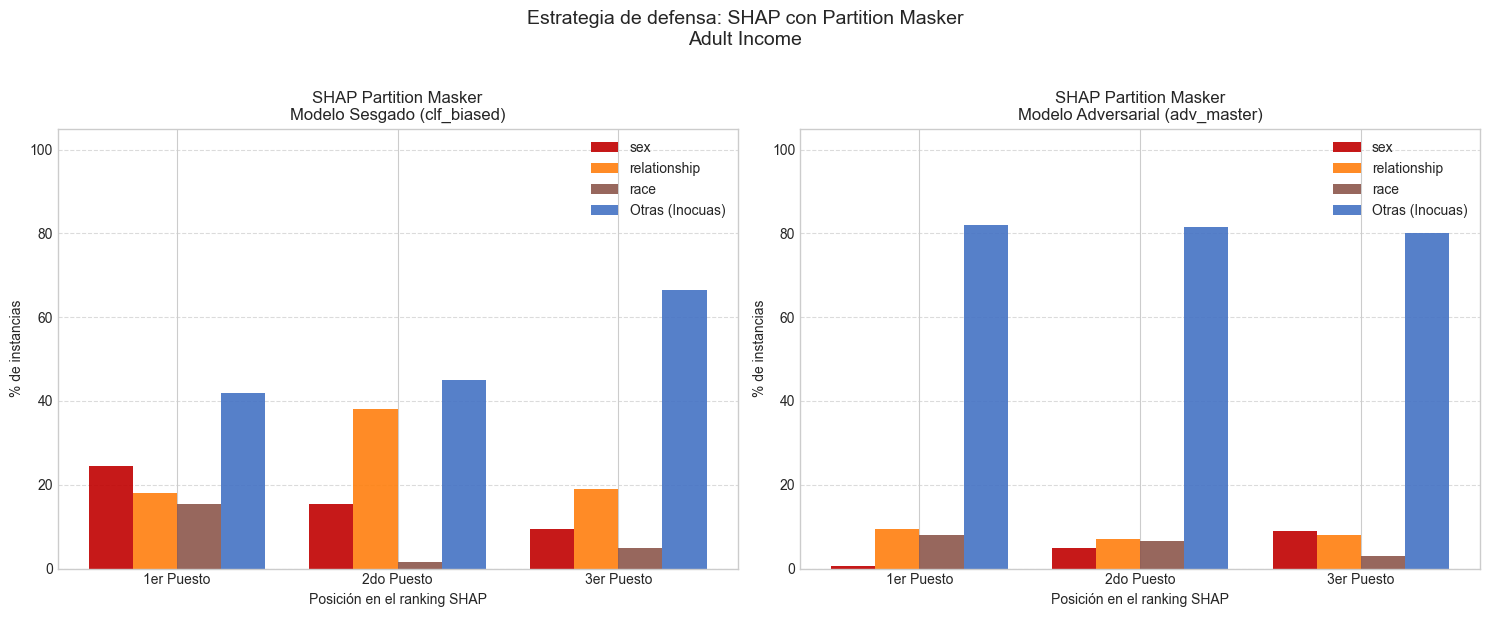


=== RESUMEN DE LA DEFENSA SHAP (Top 1) ===
Método                                          Sensibles en Top 1
-------------------------------------------------------------------
SHAP estándar (engañado)                                     11.4%
SHAP Partition Masker (defensa)                              18.0%

Referencia — modelo sesgado sin ataque:
SHAP estándar                                                65.6%
SHAP Partition Masker                                        58.0%


In [ ]:
# ── Background con Partition Masker ───────────────────────────────────────
# Partition agrupa features por correlación y las enmascara en bloques, generando perturbaciones más realistas
X_train_arr = X_train[feature_names].values
masker = shap.maskers.Partition(
    X_train_arr,
    max_samples=500,
    clustering="correlation"
)

# ── Instancias de evaluación ───────────────────────────────────────────────
N_SHAP_DEF = 200
idx_eval_def = np.random.choice(len(X_test_limpio), N_SHAP_DEF, replace=False)
X_eval_def = X_test_limpio[idx_eval_def]

overlap_def = set(map(tuple, X_eval_def)) & train_tuples
print(f"Solapamiento con train tras filtrado: {len(overlap_def)}")  # debe ser 0

# ── Explainers ─────────────────────────────────────────────────────────────
explainer_part_f = shap.PermutationExplainer(clf_biased.predict_proba, masker)
explainer_part_e = shap.PermutationExplainer(adv_master.predict_proba, masker)

# ── Evaluación modelo sesgado (referencia) ─────────────────────────────────
print(f"\nCalculando SHAP Partition — modelo sesgado ({N_SHAP_DEF} instancias)...")
t0 = time.time()
shap_part_f = explainer_part_f(X_eval_def)
print(f"✓ {time.time()-t0:.1f}s")

# ── Evaluación modelo adversarial ──────────────────────────────────────────
print(f"\nCalculando SHAP Partition — modelo adversarial ({N_SHAP_DEF} instancias)...")
adv_master.reset()
t0 = time.time()
shap_part_e = explainer_part_e(X_eval_def)
print(f"✓ {time.time()-t0:.1f}s")

print("\nRuteo SHAP Partition masker:")
adv_master.routing_report()


# ── Extracción del Top 3 ───────────────────────────────────────────────────
def get_partition_shap_top3(shap_explanation, features):
    vals = shap_explanation.values[:, :, 1]
    features_arr = np.array(features)
    return [features_arr[np.argsort(-np.abs(row))[:3]].tolist() for row in vals]


top3_f_part = get_partition_shap_top3(shap_part_f, feature_names)
top3_e_part = get_partition_shap_top3(shap_part_e, feature_names)

stats_f_part = compute_comprehensive_stats(top3_f_part, variables_vigiladas)
stats_e_part = compute_comprehensive_stats(top3_e_part, variables_vigiladas)


# ── Visualización ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (stats, title) in zip(axes, [
    (stats_f_part, 'Modelo Sesgado (clf_biased)'),
    (stats_e_part, 'Modelo Adversarial (adv_master)')
]):
    x = np.arange(3)
    for i, (feat, color) in enumerate(colors_bar.items()):
        ax.bar(x + i*0.2, stats[feat], 0.2, label=feat, color=color, alpha=0.9)
    ax.set_xticks(x + 0.3)
    ax.set_xticklabels(ranks)
    ax.set_xlabel('Posición en el ranking SHAP')
    ax.set_ylabel('% de instancias')
    ax.set_title(f'SHAP Partition Masker\n{title}')
    ax.legend()
    ax.set_ylim(0, 105)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle(
    'Estrategia de defensa: SHAP con Partition Masker\n'
    'Adult Income',
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()


# ── Resumen comparativo ────────────────────────────────────────────────────
print("\n=== RESUMEN DE LA DEFENSA SHAP (Top 1) ===")
print(f"{'Método':<45} {'Sensibles en Top 1':>20}")
print("-"*67)
print(f"{'SHAP estándar (engañado)':<45} "
      f"{sumar_sensibles(stats_e_shap, 0):>19.1f}%")
print(f"{'SHAP Partition Masker (defensa)':<45} "
      f"{sumar_sensibles(stats_e_part, 0):>19.1f}%")
print(f"\nReferencia — modelo sesgado sin ataque:")
print(f"{'SHAP estándar':<45} "
      f"{sumar_sensibles(stats_f_shap, 0):>19.1f}%")
print(f"{'SHAP Partition Masker':<45} "
      f"{sumar_sensibles(stats_f_part, 0):>19.1f}%")

Observando los resultados vemos que la defensa no ha mejorado tanto su efectividad como esperábamos. En este caso, el 18% de las instancias tienen una variable sensible en la primera posición del ranking, lo que no es muy diferente del 11% que teníamos en la versión estándar se SHAP. Sin embargo, si nos fijamos en el routing report, este método para generar perturbacione sí está consiguiendo engañar a nuestro detector, ya que más del 80% de las instancias pasan por el modelo sesgado en vez de por el inocuo.

Aunque pueda resultar contradictorio, podemos entenderlo mejor mirando la gráfica izquierda, donde se utiliza directamente el modelo sesgado. En este caso, nuestro método de generar perturbaciones hace que las variables sensibles aparezcan en primera posición para el 58% de las instancias cuando antes lo hacían para el 65% de ellas. La razón detrás de ello no es que esta defensa no sea capaz de engañar a nuestros detectores, sino que se debe a cómo distribuye el método que estamos utilizando la importancia entre las features. No obstante, aunque las variables sensibles no dominen las primeras posiciones del ranking, sería suficiente para que un auditor comenzase a sospechar de que el modelo que está auditando puede tener un comportamiento sesgado.

Si comparamos los resultados con los que obtuvimos utilizando `LimeCorrelationAware`, vemos que en este caso estamos consiguiendo engañar a los detectores en muchas más ocasiones (82% de instacias devidadas al modelo sesgado frente al 43% que obtuvimos usando la defensa de LIME), pero la forma que tiene SHAP de generar la explicación hace que el peso no esté tan concentrado como en LIME. Por ello, aunque el modelo sesgado se esté utilizando en la gran mayoría de ocasiones, la importancia que muestran las variables sensibles no es tan alta. Esto implica que la efectividad de una defensa no solo depende de cómo genera las perturbaciones, sino también de si el método de explicación utilizado es capaz de concentrar la importancia en las variables que realmente usa el modelo. En este caso, LIME es más sensible al sesgo y lo marca claramente cuando un modelo es discriminatorio pero también es más fácil de engañar en su versión estándar.

## 12. Conclusiones

Durante el desarrollo de este proyecto, hemos podido comprobar cómo es posible engañar a LIME y SHAP, dos de los métodos de explicación más utilizados. Esto lo hemos conseguido conseguido partiendo de la idea presentada en el paper "Fooling LIME and SHAP: Adversarial Attacks on Post hoc Explanation Methods" (Slack, D., Hilgard, S., Jia, E., Singh, S., & Lakkaraju, H. (2019)) para construir un sistema capaz de detectar si el dato de entrada se corresponde con un dato real o una perturbación y, dependiendo de ello, utilizar un modelo u otro para ocultar un comportamiento discriminatorio.

Este clasificador adversarial que hemos desarrollado consigue un rendimiento muy similar al que consiguen los modelos sesgado e inocuo de forma independiente, por lo que a nivel de métricas no levantaría ninguna sospecha. Además, a diferencia del paper original, que entrena un detector separado para cada método de explicación, hemos extendido el framework combinando ambos detectores con una lógica OR dentro de nuestro sistema, de forma que el adversario es capaz de engañar a LIME y SHAP simultáneamente sin conocer qué método utilizará el auditor para generar las explicaciones. Lo más destacado es que consigue engañar por completo a la versión estándar de LIME, logrando que ninguna variable sensible aparezca en las primeras posiciones de las explicaciones de las instancias evaluadas, por lo que sería imposible de detectar para un auditor. En el caso de SHAP, este ataque no es tan efectivo y el sesgo no logra ocultarse por completo ya que las perturbaciones que genera son más difíciles de distinguir de los datos reales.

No obstante, lo que más llama la atención es la efectividad que pueden llegar a tener este tipo de ataques, lo que tiene implicaciones éticas importantes. El experimento refleja que un modelo de este tipo podría ponerse en producción para tomar decisiones sobre préstamos, contrataciones o el acceso a determinados servicios y superar un proceso de auditoría que se base en estos métodos sin que el auditor detectase un comportamiento extraño. Por ello, consideramos que una organización o empresa con malas intenciones y los recursos suficientes, podría construir un sistema aún más efectivo que el que hemos desarrollado, lo que supondría un problema real.

Además, también hemos podido ver que la efectividad del tipo de sistema que estamos construyendo depende de cómo de buenos sean los detectores de perturbaciones. En nuestro caso, hemos visto que LIME en su versión estándar es muy fácil de engañar, ya que hasta los Random Forest más simples consiguen separar los datos reales de las perturbaciones de forma casi perfecta. Para SHAP, detectar las perturbaciones es algo más complicado pero aún así, el ataque fue bastante efectivo, lo que nos lleva a pensar que un atacante podría mejorar la efectividad de su engaño construyendo un detector más potente con una red neuronal, un ensemble más grande o más datos de entrenamiento, sin necesidad de modificar ningún otro componente del sistema.

Teniendo en cuenta que lo que hacía posible este tipo de ataques eran las perturbaciones generadas por LIME Y SHAP, deicidimos explorar algunas estrategias de defensa modificando la forma en que se generaban estas instancias sintéticas para que nuestros detectores no pudiesen diferenciarlas tan fácilmente de los datos reales. En el caso de LIME, primero probamos a utilizar instancias reales del conjunto de entrenamiento como vecindario local para generar la explicación, logrando que el detector no pudiese diferenciarlas y exponiendo el sesgo de nuestro sistema. Sin embargo, esta aproximación tiene limitaciones, ya que en zonas del dataset donde no haya muchos datos el vecindario no sería muy representativo y, además, estamos limitados a lo que hay en el conjunto de datos, sin poder explorar libremente cómo funciona el modelo en regiones donde el sesgo pueda ser más notable. La otra alternativa de defensa que exploramos fue generar perturbaciones a partir de una distribución normal multivariante que repetase las correlaciones entre atributos, consiguiendo también en este caso engañar al detector y exponer el sesgo del sistema, esta vez de una forma aún más efectiva. Para SHAP hemos utilizado Partition Masker para agrupar las features por correlación y enmascararlas conjuntamente para dar lugar a instancias más realistas. En este caso la mejora no fue tan notable como en LIME, ya que SHAP tiende a distribuir la importancia entre más variables, logrando exponer el sesgo pero no de forma tan destacada. 

En definitiva, estas defensas muestran cómo es posible hacer frente a un ataque de este tipo para que LIME y SHAP no sean engañados, pero también reflejan la importancia y la necesidad de hacer auditorías cuidadosas y detalladas utilizando todos los recursos disponibles para asegurar que no se introduce ningún comportamiento discriminatorio en estos modelos. Por ello, en una situación real sería de gran ayuda tener una mayor transparencia sobre cómo se ha construido el modelo, por ejemplo teniendo acceso a los datos de entrenamiento para comprobar si han sido manipulados o si se ha introducido una lógica de detección como la que hemos implementado para ocultar sesgos, lo que dificultaría notablemente las cosas para los atacantes.

### Limitaciones y trabajo futuro

Tras haber explorado cómo funcionan los ataques sobre LIME y SHAP, junto con algunas posibles estrategias de defensa, proponemos algunas líneas de trabajo futuro con las qu extender el trabajo:

- **Defensas basadas en modelos generativos:** Aunque las estrategias de defensa implementadas demostraron ser eficaces para exponer el sesgo de nuestro modelo, sería interesante explorar técnicas que aprendiesen la distribución real de los datos y utilizar modelos generativos, como GANs o Autoencoders Variacionales (VAEs), para generar instancias sintéticas que se parezcan mucho más a los datos reales y confundan completamente a los detectores, haciendo que el ataque adversario no sea efectivo.

- **Extender el proyecto para utilizar datos no tabulares como texto o imágenes:** Nosotros hemos trabajado con datos tabulares, donde las perturbaciones se generan cambiando los valores de las diferentes features. Sin embargo, como estos métodos también pueden usarse para explicar texto e imágenes, podría evaluarse la viabilidad de este tipo de ataques sobre diferentes tipos de datos.

- **Evaluación de otros métodos de explicabilidad post-hoc:** El ataque que hemos llevado a cabo podría expandirse para utilizarse con otros métodos de explicación como anchors o counterfactuales, comprobando si las explicaciones generadas con estos métodos también pueden ser manipuladas con fines no éticos o discriminatorios.

---
## Referencias

* Díaz Agudo, M. B. (2026). *Técnicas de Inteligencia Artificial Explicable*. [Apuntes y notebooks de clase]. Universidad Complutense de Madrid.
* Becker, B. & Kohavi, R. (1996). Adult [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20.
* Slack, D., Hilgard, S., Jia, E., Singh, S., & Lakkaraju, H. (2019). *How can we fool LIME and SHAP? Adversarial Attacks on Post hoc Explanation Methods*. arXiv preprint arXiv:1911.02508. https://arxiv.org/abs/1911.02508
* Lundberg, S. M. (2026). *SHAP: A game theoretic approach to explain the output of any machine learning model*. [Documentation]. https://shap.readthedocs.io/en/latest/index.html
* Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *"Why Should I Trust You?": Explaining the Predictions of Any Classifier*. arXiv preprint arXiv:1602.04938. https://arxiv.org/abs/1602.04938